<a href="https://colab.research.google.com/github/jonasknoll57/Bachelorarbeit_Demand-AD/blob/main/V20_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# V17c — Cross-City Pair Comparison

**Zweck:** Robustheits-/Pair-Comparison-Phase.
Prueft ob das Transfer-Ergebnis aus V17b (HD -> MA) ein Sonderfall war oder
sich ueber mehrere Targets und Source-Paare bestaetigt.

**Leitfragen:**
1. Ist Strict Zero-Shot bei aehnlichen Sources (+) systematisch besser als bei unaehnlicheren (-)?
2. Bringt Fine-Tune 5% das Modell konsistent naeher an das Oracle?
3. Ist Transfer besser als Target-only 5%?
4. Bleibt das Ergebnisbild ueber mehrere Targets hinweg plausibel?

**Targets:** Mannheim, Freiburg, Braunschweig
**Experimente pro Target:** Oracle 100%, Target-only 5%, ZS Strict (+), ZS Strict (-), FT 5% (+), FT 5% (-)
**Modell:** LSTM Forecaster (directional scoring + Z-Norm)
**Anomalietypen:** point_spike, point_drop, collective (keine contextuals)


In [1]:
# 0a — Colab Setup
from google.colab import drive
drive.mount('/content/drive', force_remount=False)


Mounted at /content/drive


In [2]:
# 0b — Imports
import os, math, json, random, warnings, time, re, glob, copy, pickle
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd

from scipy.stats import poisson
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, precision_recall_curve,
    classification_report
)
from numpy.lib.stride_tricks import sliding_window_view

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
print(f"TF {tf.__version__}, GPU: {tf.config.list_physical_devices('GPU')}")


TF 2.19.0, GPU: []


In [3]:
# 0c — V17c Config
DATA_BASE    = '/content/drive/MyDrive/BA_Colab/data'
CLEANED_BASE = '/content/drive/MyDrive/BA_Colab/cleaned'

RUN_NAME    = 'v17c_pair_comparison'
RESULTS_DIR = f'{DATA_BASE}/{RUN_NAME}'
MODELS_DIR  = f'{RESULTS_DIR}/models'
V17_MODELS  = f'{DATA_BASE}/v17_ad_improvements/models'
V17B_MODELS = f'{DATA_BASE}/v17b_transfer_sanity/models'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

geo_path           = f'{CLEANED_BASE}/geo_information/geo_information.parquet'
station_names_path = f'{DATA_BASE}/station_names/station_names.parquet'

CITY_DEMAND = {
    "Mannheim":       f'{CLEANED_BASE}/demand/Mannheim/demand_cleaned.parquet',
    "Heidelberg":     f'{CLEANED_BASE}/demand/Heidelberg/demand_cleaned.parquet',
    "Marburg":        f'{CLEANED_BASE}/demand/Marburg/demand_cleaned.parquet',
    "Freiburg":       f'{CLEANED_BASE}/demand/Freiburg/demand_cleaned.parquet',
    "Ludwigshafen":   f'{CLEANED_BASE}/demand/Ludwigshafen/demand_cleaned.parquet',
    "Braunschweig":   f'{CLEANED_BASE}/demand/Braunschweig/demand_cleaned.parquet',
    "Kaiserslautern": f'{CLEANED_BASE}/demand/Kaiserslautern/demand_cleaned.parquet',
}

EXPERIMENT_PAIRS = {
    "Mannheim": [
        ("Heidelberg", "+"),
        ("Marburg",    "-"),
    ],
    "Freiburg": [
        ("Heidelberg",   "+"),
        ("Ludwigshafen", "-"),
    ],
    "Braunschweig": [
        ("Mannheim",       "+"),
        ("Kaiserslautern", "-"),
    ],
}

@dataclass
class V17cConfig:
    aggregation_minutes: int = 60
    train_ratio: float = 0.67
    val_ratio: float = 0.82
    min_events_per_day: float = 3.0
    rolling_days: int = 56
    min_context_obs: int = 20
    ae_window_size: int = 24
    ae_latent_dim: int = 32
    ae_layers: int = 2
    ae_dropout: float = 0.10
    ae_epochs: int = 50
    ae_batch_size: int = 2048
    ae_lr: float = 1e-3
    ae_early_stop: int = 8
    eval_batch_size: int = 2048
    low_demand_q: float = 0.33
    high_demand_q: float = 0.67
    require_contiguous: bool = True
    use_bidirectional: bool = False
    ae_features: List[str] = field(default_factory=lambda: [
        "n_lends", "n_returns",
        "hour_sin", "hour_cos", "dow_sin", "dow_cos",
        "month_sin", "month_cos", "is_weekend"
    ])
    ae_score_features: List[str] = field(default_factory=lambda: ["n_lends", "n_returns"])
    injection_rate: float = 0.015
    injection_seed: int = 42
    finetune_ratio: float = 0.05

cfg = V17cConfig()
print(cfg)
print(f"\nResults: {RESULTS_DIR}")
print(f"V17 Models: {V17_MODELS}")
print(f"V17b Models: {V17B_MODELS}")

print("\n--- Demand-Dateien ---")
for city, path in CITY_DEMAND.items():
    exists = os.path.exists(path)
    print(f"  {city:18s}: {'OK' if exists else 'FEHLT!'} -- {path}")


V17cConfig(aggregation_minutes=60, train_ratio=0.67, val_ratio=0.82, min_events_per_day=3.0, rolling_days=56, min_context_obs=20, ae_window_size=24, ae_latent_dim=32, ae_layers=2, ae_dropout=0.1, ae_epochs=50, ae_batch_size=2048, ae_lr=0.001, ae_early_stop=8, eval_batch_size=2048, low_demand_q=0.33, high_demand_q=0.67, require_contiguous=True, use_bidirectional=False, ae_features=['n_lends', 'n_returns', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend'], ae_score_features=['n_lends', 'n_returns'], injection_rate=0.015, injection_seed=42, finetune_ratio=0.05)

Results: /content/drive/MyDrive/BA_Colab/data/v17c_pair_comparison
V17 Models: /content/drive/MyDrive/BA_Colab/data/v17_ad_improvements/models
V17b Models: /content/drive/MyDrive/BA_Colab/data/v17b_transfer_sanity/models

--- Demand-Dateien ---
  Mannheim          : OK -- /content/drive/MyDrive/BA_Colab/cleaned/demand/Mannheim/demand_cleaned.parquet
  Heidelberg        : OK -- /content/drive/MyD

---
## Shared Functions (aus V17b uebernommen, unveraendert)


In [4]:
# 1 — Aggregation
def aggregate_station_level(df: pd.DataFrame, minutes: int = 60,
                            add_relative: bool = False) -> pd.DataFrame:
    out = df.copy()
    freq = f"{minutes}min"
    out["time_bin"] = out["timestamp"].dt.floor(freq)
    agg = (
        out.groupby(
            ["station_id", "station_name_id", "station_name", "location_id", "time_bin"],
            as_index=False
        )
        .agg({"n_lends": "sum", "n_returns": "sum", "latitude": "first", "longitude": "first"})
        .rename(columns={"time_bin": "hour_ts"})
    )
    agg["total_demand"] = agg["n_lends"] + agg["n_returns"]
    agg["net_flow"] = agg["n_returns"] - agg["n_lends"]
    agg["abs_net_flow"] = agg["net_flow"].abs()
    agg["hour"] = agg["hour_ts"].dt.hour
    agg["dow"] = agg["hour_ts"].dt.dayofweek
    agg["month"] = agg["hour_ts"].dt.month
    agg["is_weekend"] = agg["dow"].isin([5, 6]).astype(int)
    agg["hour_sin"] = np.sin(2 * np.pi * agg["hour"] / 24)
    agg["hour_cos"] = np.cos(2 * np.pi * agg["hour"] / 24)
    agg["dow_sin"]  = np.sin(2 * np.pi * agg["dow"] / 7)
    agg["dow_cos"]  = np.cos(2 * np.pi * agg["dow"] / 7)
    agg["month_sin"] = np.sin(2 * np.pi * (agg["month"] - 1) / 12)
    agg["month_cos"] = np.cos(2 * np.pi * (agg["month"] - 1) / 12)
    agg = agg.sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    return agg


In [5]:
# 2 — Gap-Fill
def fill_missing_time_bins(x: pd.DataFrame, minutes: int = 60) -> pd.DataFrame:
    freq = f"{minutes}min"
    parts = []
    x = x.copy().sort_values(["station_id", "hour_ts"])
    x = (
        x.groupby(["station_id", "hour_ts"], as_index=False)
         .agg({
             "station_name_id": "first", "station_name": "first",
             "location_id": "first", "latitude": "first",
             "longitude": "first", "n_lends": "sum", "n_returns": "sum",
         })
    )
    key_cols = ["station_id", "station_name_id", "station_name",
                "location_id", "latitude", "longitude"]
    for sid, g in x.groupby("station_id", sort=False):
        g = g.sort_values("hour_ts").copy()
        full_idx = pd.date_range(g["hour_ts"].min(), g["hour_ts"].max(), freq=freq)
        g = g.set_index("hour_ts").reindex(full_idx)
        g.index.name = "hour_ts"
        g["n_lends"]   = g["n_lends"].fillna(0).astype(int)
        g["n_returns"] = g["n_returns"].fillna(0).astype(int)
        for col in key_cols:
            g[col] = g[col].ffill().bfill()
        parts.append(g.reset_index())
    result = pd.concat(parts, ignore_index=True)
    result["total_demand"] = result["n_lends"] + result["n_returns"]
    result["net_flow"]     = result["n_returns"] - result["n_lends"]
    result["abs_net_flow"] = result["net_flow"].abs()
    result["hour"] = result["hour_ts"].dt.hour
    result["dow"]  = result["hour_ts"].dt.dayofweek
    result["month"] = result["hour_ts"].dt.month
    result["is_weekend"] = result["dow"].isin([5, 6]).astype(int)
    result["hour_sin"]  = np.sin(2 * np.pi * result["hour"] / 24)
    result["hour_cos"]  = np.cos(2 * np.pi * result["hour"] / 24)
    result["dow_sin"]   = np.sin(2 * np.pi * result["dow"] / 7)
    result["dow_cos"]   = np.cos(2 * np.pi * result["dow"] / 7)
    result["month_sin"] = np.sin(2 * np.pi * (result["month"] - 1) / 12)
    result["month_cos"] = np.cos(2 * np.pi * (result["month"] - 1) / 12)
    return result.sort_values(["station_id", "hour_ts"]).reset_index(drop=True)


In [6]:
# 3 — Station-Filter, Demand-Regime, Train/Val/Test Split
def prepare_stations_and_splits(df: pd.DataFrame, cfg, city_name=""):
    n_days = (df["hour_ts"].max() - df["hour_ts"].min()).days + 1
    min_events = int(n_days * cfg.min_events_per_day)
    station_volume = df.groupby("station_id")["total_demand"].sum()
    active_ids = station_volume[station_volume >= min_events].index.tolist()
    df = df[df["station_id"].isin(active_ids)].copy()
    station_profile = (
        df.groupby(["station_id", "station_name"], as_index=False)
          .agg(
              avg_total_demand_h=("total_demand", "mean"),
              avg_lends_h=("n_lends", "mean"),
              avg_returns_h=("n_returns", "mean"),
              latitude=("latitude", "first"),
              longitude=("longitude", "first")
          )
    )
    q1 = station_profile["avg_total_demand_h"].quantile(cfg.low_demand_q)
    q2 = station_profile["avg_total_demand_h"].quantile(cfg.high_demand_q)
    station_profile["demand_regime"] = station_profile["avg_total_demand_h"].apply(
        lambda x: "low" if x <= q1 else ("mid" if x <= q2 else "high")
    )
    df = df.merge(
        station_profile[["station_id", "demand_regime", "avg_total_demand_h"]],
        on="station_id", how="left"
    )
    t_min = df["hour_ts"].min()
    t_max = df["hour_ts"].max()
    total_h = (t_max - t_min).total_seconds() / 3600
    train_end = t_min + pd.Timedelta(hours=int(total_h * cfg.train_ratio))
    val_end   = t_min + pd.Timedelta(hours=int(total_h * cfg.val_ratio))
    cn = f" ({city_name})" if city_name else ""
    print(f"  Aktive Stationen{cn}: {df['station_id'].nunique()}")
    print(f"  Regime: {station_profile['demand_regime'].value_counts().to_dict()}")
    print(f"  Zeitraum: {t_min.date()} bis {t_max.date()} ({n_days} Tage)")
    print(f"  Split: Train < {train_end.date()}, Val < {val_end.date()}, Test ab {val_end.date()}")
    return df, station_profile, train_end, val_end


In [7]:
# 4 — Rolling Context z-Scores + Poisson + ECDF + Labels
TARGETS = ["n_lends", "n_returns", "net_flow", "total_demand"]
COUNT_TARGETS = ["n_lends", "n_returns", "total_demand"]

def add_context_keys(x):
    x = x.copy()
    x["ctx_hour"] = x["hour_ts"].dt.hour
    x["ctx_dow"]  = x["hour_ts"].dt.dayofweek
    return x

def rolling_context_scores_vectorized(full_df, target, rolling_days=56, min_obs=20):
    x = full_df.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    mu_col = f"{target}_mu_ctx_roll"
    sd_col = f"{target}_sd_ctx_roll"
    score_col = f"{target}_z_ctx_roll"
    n_slots = max(rolling_days // 7, 4)
    main_window = n_slots
    main_minp = min(min_obs, main_window)
    grouped = x.groupby(["station_id", "ctx_hour", "ctx_dow"])[target]
    rolling_mean = grouped.transform(lambda s: s.shift(1).rolling(window=main_window, min_periods=main_minp).mean())
    rolling_std = grouped.transform(lambda s: s.shift(1).rolling(window=main_window, min_periods=main_minp).std(ddof=0))
    fb1_window = n_slots * 2
    fb1_minp = min(min_obs, fb1_window)
    grouped_sh = x.groupby(["station_id", "ctx_hour"])[target]
    fb1_mean = grouped_sh.transform(lambda s: s.shift(1).rolling(window=fb1_window, min_periods=fb1_minp).mean())
    fb1_std = grouped_sh.transform(lambda s: s.shift(1).rolling(window=fb1_window, min_periods=fb1_minp).std(ddof=0))
    fb2_window = n_slots * 4
    fb2_minp = min(min_obs, fb2_window)
    grouped_s = x.groupby(["station_id"])[target]
    fb2_mean = grouped_s.transform(lambda s: s.shift(1).rolling(window=fb2_window, min_periods=fb2_minp).mean())
    fb2_std = grouped_s.transform(lambda s: s.shift(1).rolling(window=fb2_window, min_periods=fb2_minp).std(ddof=0))
    mu = rolling_mean.copy()
    sd = rolling_std.copy()
    mask1 = mu.isna()
    mu = mu.where(~mask1, fb1_mean)
    sd = sd.where(~mask1, fb1_std)
    mask2 = mu.isna()
    mu = mu.where(~mask2, fb2_mean)
    sd = sd.where(~mask2, fb2_std)
    sd = sd.clip(lower=1e-6)
    z = (x[target] - mu) / sd
    x[mu_col] = mu
    x[sd_col] = sd
    x[score_col] = z
    return x

def add_rolling_poisson_scores_vectorized(full_df, target, rolling_days=56, min_obs=20):
    x = full_df.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    lam_col = f"{target}_lambda_ctx_roll"
    score_col = f"{target}_poisson_upper_score"
    score_low_col = f"{target}_poisson_lower_score"
    mu_col = f"{target}_mu_ctx_roll"
    if mu_col not in x.columns:
        raise ValueError(f"{mu_col} muss zuerst berechnet werden")
    x[lam_col] = x[mu_col].clip(lower=1e-6)
    vals = x[target].values
    lams = x[lam_col].values
    with np.errstate(divide='ignore', invalid='ignore'):
        tail_p = poisson.sf(vals.astype(float) - 1, lams.astype(float))
        score = -np.log10(np.clip(tail_p, 1e-12, None))
        lower_p = poisson.cdf(vals.astype(float), lams.astype(float))
        score_low = -np.log10(np.clip(lower_p, 1e-12, None))
    mask_nan = np.isnan(lams)
    score[mask_nan] = np.nan
    score_low[mask_nan] = np.nan
    x[score_col] = score
    x[score_low_col] = score_low
    return x

def percentile_score(train_vals, values):
    train_vals = np.asarray(train_vals, dtype=float)
    values = np.asarray(values, dtype=float)
    train_vals = train_vals[np.isfinite(train_vals)]
    if len(train_vals) == 0:
        return np.full(len(values), np.nan, dtype=float)
    train_sorted = np.sort(train_vals)
    ranks = np.searchsorted(train_sorted, values, side="right")
    return ranks / len(train_sorted)

def calibrate_scores_by_station(full_df, train_mask, raw_score_cols):
    x = full_df.copy()
    for col in raw_score_cols:
        if col not in x.columns:
            continue
        pct_col = f"{col}_pct_station"
        x[pct_col] = np.nan
        for sid, grp in x.groupby("station_id", sort=False):
            idx_all = grp.index
            idx_train = grp.index[train_mask.loc[idx_all]]
            train_vals = x.loc[idx_train, col].to_numpy(dtype=float) if len(idx_train) > 0 else np.array([])
            vals = x.loc[idx_all, col].to_numpy(dtype=float)
            x.loc[idx_all, pct_col] = percentile_score(train_vals, vals)
    return x

def build_eval_labels_calibrated(x):
    y = x.copy()
    y["label_eval"] = "normal"
    z_up = "total_demand_score_upper_pct_station"
    z_low = "total_demand_score_lower_pct_station"
    p_up = "total_demand_poisson_upper_score_pct_station"
    p_low = "total_demand_poisson_lower_score_pct_station"
    required = [z_up, z_low, p_up, p_low]
    missing = [c for c in required if c not in y.columns]
    if missing:
        raise ValueError(f"Fehlende Spalten: {missing}")
    td = y["total_demand"].fillna(0)
    mu = y["total_demand_mu_ctx_roll"]
    abs_min_high = np.maximum(5, np.ceil(mu + 2)).fillna(5)
    abs_min_low_ref = np.maximum(3, np.ceil(mu)).fillna(3)
    high_strong = ((y[z_up] >= 0.995) | (y[p_up] >= 0.995)) & (td >= abs_min_high)
    high_consensus = ((y[z_up] >= 0.99) & (y[p_up] >= 0.99)) & (td >= abs_min_high)
    cond_high = high_strong | high_consensus
    low_possible = mu >= abs_min_low_ref
    low_strong = ((y[z_low] >= 0.999) | (y[p_low] >= 0.999)) & low_possible
    low_consensus = ((y[z_low] >= 0.995) & (y[p_low] >= 0.995)) & low_possible
    cond_low = (low_strong | low_consensus) & ~cond_high
    grau_high = ((y[z_up] >= 0.99) | (y[p_up] >= 0.99)) & ~cond_high & ~cond_low
    grau_low = ((y[z_low] >= 0.99) | (y[p_low] >= 0.99)) & ~cond_high & ~cond_low & ~grau_high
    y.loc[grau_high, "label_eval"] = "grauzone_high"
    y.loc[grau_low, "label_eval"] = "grauzone_low"
    y.loc[cond_high, "label_eval"] = "anomal_high"
    y.loc[cond_low, "label_eval"] = "anomal_low"
    return y

def run_statistical_pipeline(df, cfg, train_end):
    print("  [1/5] Kontext-Keys...")
    df = add_context_keys(df)
    print("  [2/5] Rolling z-Scores...")
    for tgt in TARGETS:
        df = rolling_context_scores_vectorized(df, target=tgt, rolling_days=cfg.rolling_days, min_obs=cfg.min_context_obs)
    for tgt in TARGETS:
        zc = f"{tgt}_z_ctx_roll"
        df[f"{tgt}_score_upper"] = df[zc]
        df[f"{tgt}_score_lower"] = -df[zc]
    print("  [3/5] Poisson-Tail-Scores...")
    for tgt in COUNT_TARGETS:
        df = add_rolling_poisson_scores_vectorized(df, target=tgt, rolling_days=cfg.rolling_days, min_obs=cfg.min_context_obs)
    print("  [4/5] ECDF-Kalibrierung...")
    raw_score_cols = []
    for tgt in TARGETS:
        raw_score_cols += [f"{tgt}_score_upper", f"{tgt}_score_lower"]
    for tgt in COUNT_TARGETS:
        raw_score_cols += [f"{tgt}_poisson_upper_score", f"{tgt}_poisson_lower_score"]
    train_mask = df["hour_ts"] < train_end
    df = calibrate_scores_by_station(df, train_mask, raw_score_cols)
    print("  [5/5] Labels...")
    df = build_eval_labels_calibrated(df)
    anomaly_rate = df["label_eval"].isin(["anomal_high", "anomal_low"]).mean()
    print(f"  Label-Verteilung:")
    print(f"    {df['label_eval'].value_counts().to_dict()}")
    print(f"    Anomalie-Rate: {anomaly_rate:.4f} ({anomaly_rate*100:.2f}%)")
    return df


In [8]:
# 5 — Sequenzbuilder (Window-Level Labels)
def make_sequences_with_window_labels(
    x, feature_cols, window_size,
    synth_label_col="synth_label", synth_type_col="synth_type",
    require_contiguous=True, agg_minutes=60
):
    X_parts, meta_parts = [], []
    expected_ns = pd.Timedelta(minutes=agg_minutes).value
    for sid, g in x.groupby("station_id", sort=False):
        g = g.sort_values("hour_ts").reset_index(drop=True)
        n = len(g)
        if n < window_size:
            continue
        vals = g[feature_cols].to_numpy(dtype=np.float32)
        win = sliding_window_view(vals, window_shape=window_size, axis=0)
        win = np.moveaxis(win, -1, 1)
        valid_mask = np.ones(n - window_size + 1, dtype=bool)
        if require_contiguous:
            ts_int = pd.to_datetime(g["hour_ts"]).astype("int64").to_numpy()
            diffs = np.diff(ts_int)
            step_ok = (diffs == expected_ns).astype(np.int8)
            if window_size > 1:
                ok_sums = np.convolve(step_ok, np.ones(window_size-1, dtype=np.int32), mode="valid")
                valid_mask = (ok_sums == (window_size - 1))
        if not valid_mask.any():
            continue
        end_indices = np.arange(window_size - 1, n)[valid_mask]
        X_parts.append(win[valid_mask])
        meta_chunk = g.iloc[end_indices].copy()
        synth_arr = g[synth_label_col].to_numpy()
        type_arr = g[synth_type_col].to_numpy()
        window_labels, window_types, window_counts = [], [], []
        for end_idx in end_indices:
            start_idx = end_idx - window_size + 1
            window_synth = synth_arr[start_idx:end_idx + 1]
            window_type = type_arr[start_idx:end_idx + 1]
            has_synth = int(window_synth.max())
            n_synth = int(window_synth.sum())
            if has_synth:
                synth_positions = np.where(window_synth == 1)[0]
                wtype = window_type[synth_positions[-1]]
            else:
                wtype = "none"
            window_labels.append(has_synth)
            window_types.append(wtype)
            window_counts.append(n_synth)
        meta_chunk["window_synth_label"] = window_labels
        meta_chunk["window_synth_type"] = window_types
        meta_chunk["n_synth_in_window"] = window_counts
        meta_parts.append(meta_chunk)
    if X_parts:
        X = np.concatenate(X_parts, axis=0)
        meta = pd.concat(meta_parts, axis=0).reset_index(drop=True)
    else:
        X = np.empty((0, window_size, len(feature_cols)), dtype=np.float32)
        meta = pd.DataFrame()
    return X, meta


In [9]:
# 6 — Model Builder (Forecaster) + Training
def build_lstm_forecaster(n_input_features, n_output_features,
                          context_steps=23, latent_dim=32, n_layers=2, dropout=0.1):
    inputs = keras.Input(shape=(context_steps, n_input_features), name="forecast_input")
    x = inputs
    for i in range(n_layers):
        return_sequences = (i < n_layers - 1)
        x = layers.LSTM(latent_dim, return_sequences=return_sequences,
                        dropout=dropout, name=f"forecast_lstm_{i+1}")(x)
    outputs = layers.Dense(n_output_features, name="forecast_output")(x)
    return keras.Model(inputs, outputs, name="lstm_forecaster")

def train_model_generic(model, X_train, Y_train, X_val, Y_val,
                        epochs, lr, batch_size, early_stop, verbose=1):
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0), loss="mse")
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=early_stop,
                                      restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, verbose=1)
    ]
    history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val),
                        epochs=epochs, batch_size=batch_size, callbacks=callbacks, verbose=verbose)
    return model, history


In [10]:
# 7 — Scoring Helpers (Forecaster)
def predict_in_batches(model, X, batch_size=2048):
    preds = []
    for i in range(0, len(X), batch_size):
        preds.append(model.predict(X[i:i + batch_size], verbose=0))
    return np.concatenate(preds, axis=0) if preds else np.empty((0, 0), dtype=np.float32)

def compute_forecast_scores(model, X_input, X_actual_last_step, score_features,
                            ae_features, mode="directional"):
    X_pred = predict_in_batches(model, X_input, batch_size=2048)
    sc_idx = [ae_features.index(f) for f in score_features]
    X_actual = X_actual_last_step[:, sc_idx]
    err = (X_pred - X_actual) ** 2
    if mode == "mean":
        return err.mean(axis=1)
    elif mode == "max":
        return err.max(axis=1)
    elif mode == "directional":
        abs_err = np.abs(X_pred - X_actual)
        denom = np.maximum(np.maximum(np.abs(X_actual), np.abs(X_pred)), 1e-6)
        rel_err = abs_err / denom
        return 0.5 * abs_err.mean(axis=1) + 0.5 * rel_err.mean(axis=1)
    else:
        raise ValueError(f"Unbekannter mode: {mode}")


In [11]:
# 8 — Z-Normalisierung
def znorm_score_by_hour(meta_df, raw_score_col, val_start, test_start,
                        new_col="score_znorm_hour"):
    """Hour-only Z-Norm. Returns (meta, mu_per_hour, std_per_hour)."""
    meta = meta_df.copy()
    val_normal = (
        (meta["hour_ts"] >= val_start) &
        (meta["hour_ts"] < test_start) &
        (meta["synth_label"] == 0)
    )
    hour_col = meta["hour_ts"].dt.hour
    mu_per_hour, std_per_hour = {}, {}
    for h in range(24):
        vals = meta.loc[val_normal & (hour_col == h), raw_score_col].dropna()
        mu_per_hour[h] = vals.mean() if len(vals) > 0 else 0.0
        std_per_hour[h] = vals.std() if len(vals) > 1 else 1.0
    hours = hour_col.values
    raw = meta[raw_score_col].values
    znorm = np.zeros_like(raw)
    for i in range(len(raw)):
        znorm[i] = (raw[i] - mu_per_hour[hours[i]]) / max(std_per_hour[hours[i]], 1e-8)
    meta[new_col] = znorm
    return meta, mu_per_hour, std_per_hour

def znorm_score_by_hour_station(meta_df, raw_score_col, val_start, test_start,
                                new_col="score_znorm_hour_station"):
    """Hour x Station Z-Norm (with global fallback)."""
    meta = meta_df.copy()
    val_normal = (
        (meta["hour_ts"] >= val_start) &
        (meta["hour_ts"] < test_start) &
        (meta["synth_label"] == 0)
    )
    hour_col = meta["hour_ts"].dt.hour
    meta["_hour_tmp"] = hour_col
    stats = (meta[val_normal].groupby(["station_id", "_hour_tmp"])[raw_score_col]
             .agg(["mean", "std", "count"]).reset_index())
    global_stats = (meta[val_normal].groupby("_hour_tmp")[raw_score_col]
                    .agg(["mean", "std"]).reset_index()
                    .rename(columns={"mean": "g_mean", "std": "g_std"}))
    stats = stats.merge(global_stats, on="_hour_tmp", how="left")
    stats["use_mean"] = np.where(stats["count"] >= 10, stats["mean"], stats["g_mean"])
    stats["use_std"] = np.where(stats["count"] >= 10, stats["std"], stats["g_std"])
    stats["use_std"] = stats["use_std"].clip(lower=1e-8)
    meta = meta.merge(stats[["station_id", "_hour_tmp", "use_mean", "use_std"]],
                      on=["station_id", "_hour_tmp"], how="left")
    meta["use_mean"] = meta["use_mean"].fillna(0.0)
    meta["use_std"] = meta["use_std"].fillna(1.0).clip(lower=1e-8)
    meta[new_col] = (meta[raw_score_col] - meta["use_mean"]) / meta["use_std"]
    meta = meta.drop(columns=["_hour_tmp", "use_mean", "use_std"])
    return meta

def apply_znorm_with_external_stats(meta_df, raw_score_col, mu_per_hour, std_per_hour,
                                     new_col="score_znorm_transfer"):
    """Apply Z-Norm using pre-computed hour-level stats (from source city)."""
    meta = meta_df.copy()
    hours = meta["hour_ts"].dt.hour.values
    raw = meta[raw_score_col].values
    znorm = np.zeros_like(raw)
    for i in range(len(raw)):
        h = hours[i]
        znorm[i] = (raw[i] - mu_per_hour.get(h, 0.0)) / max(std_per_hour.get(h, 1.0), 1e-8)
    meta[new_col] = znorm
    return meta


In [12]:
# 9 — Synthetic Injection (ohne Contextuals)
V17B_INJECTION_PROBS = {"point_spike": 0.467, "point_drop": 0.400, "collective": 0.133}
V17B_COLLECTIVE_BLOCK_LEN = (2, 4)

def inject_synthetic_anomalies_v17b(df, inject_start, injection_rate=0.015,
                                     seed=42, verbose=True):
    probs = list(V17B_INJECTION_PROBS.values())
    type_names = list(V17B_INJECTION_PROBS.keys())
    block_min, block_max = V17B_COLLECTIVE_BLOCK_LEN
    rng = np.random.RandomState(seed)
    out = df.copy()
    out["original_n_lends"] = out["n_lends"].copy()
    out["original_n_returns"] = out["n_returns"].copy()
    out["synth_label"] = 0
    out["synth_type"] = "none"
    inject_mask = out["hour_ts"] >= inject_start
    inject_idx = out[inject_mask].index.to_numpy()
    if len(inject_idx) == 0:
        print("  WARNUNG: Keine Daten ab inject_start!")
        return out
    n_inject = max(1, int(len(inject_idx) * injection_rate))
    inject_df = out.loc[inject_idx]
    has_demand = inject_df[inject_df["total_demand"] > 0].index.to_numpy()
    if len(has_demand) < n_inject:
        n_inject = len(has_demand)
    chosen_idx = rng.choice(has_demand, size=n_inject, replace=False)
    types = rng.choice(type_names, size=n_inject, p=probs)
    injected_indices = set()
    requested_counts = {t: 0 for t in type_names}
    injected_counts = {t: 0 for t in type_names}
    for idx, anom_type in zip(chosen_idx, types):
        requested_counts[anom_type] += 1
        if idx in injected_indices:
            continue
        row = out.loc[idx]
        if anom_type == "point_spike":
            factor = rng.uniform(3.0, 8.0)
            out.loc[idx, "n_lends"] = int(row["n_lends"] * factor) + rng.randint(2, 10)
            out.loc[idx, "n_returns"] = int(row["n_returns"] * factor) + rng.randint(2, 10)
            out.loc[idx, "synth_label"] = 1
            out.loc[idx, "synth_type"] = "point_spike"
            injected_indices.add(idx)
            injected_counts["point_spike"] += 1
        elif anom_type == "point_drop":
            regime = row.get("demand_regime", "low")
            do_drop = (regime == "high" and row["total_demand"] >= 8) or                       (regime == "mid" and row["total_demand"] >= 5)
            if do_drop:
                out.loc[idx, "n_lends"] = rng.randint(0, 2)
                out.loc[idx, "n_returns"] = rng.randint(0, 2)
                out.loc[idx, "synth_label"] = 1
                out.loc[idx, "synth_type"] = "point_drop"
                injected_indices.add(idx)
                injected_counts["point_drop"] += 1
        elif anom_type == "collective":
            block_len = rng.randint(block_min, block_max + 1)
            sid = row["station_id"]
            station_inject = out[(out["station_id"] == sid) & inject_mask].sort_values("hour_ts")
            if idx in station_inject.index:
                pos = station_inject.index.get_loc(idx)
                if pos + block_len <= len(station_inject):
                    block_idx = station_inject.index[pos:pos + block_len]
                    factor = rng.uniform(2.5, 5.0)
                    block_actually = 0
                    for bidx in block_idx:
                        if bidx not in injected_indices:
                            out.loc[bidx, "n_lends"] = int(out.loc[bidx, "original_n_lends"] * factor) + rng.randint(1, 5)
                            out.loc[bidx, "n_returns"] = int(out.loc[bidx, "original_n_returns"] * factor) + rng.randint(1, 5)
                            out.loc[bidx, "synth_label"] = 1
                            out.loc[bidx, "synth_type"] = "collective"
                            injected_indices.add(bidx)
                            block_actually += 1
                    injected_counts["collective"] += block_actually
    out["total_demand"] = out["n_lends"] + out["n_returns"]
    out["net_flow"] = out["n_returns"] - out["n_lends"]
    out["abs_net_flow"] = out["net_flow"].abs()
    n_injected = out["synth_label"].sum()
    inject_total = inject_mask.sum()
    if verbose:
        print(f"\n  Synthetic Injection (ohne Contextuals):")
        print(f"    Inject-Zeilen gesamt:  {inject_total:,}")
        print(f"    Injizierte Punkte:     {n_injected:,} ({n_injected/inject_total*100:.2f}%)")
        print(f"\n    Requested vs Actually Injected:")
        for t in type_names:
            print(f"      {t:15s}  requested={requested_counts[t]:5d}  injected={injected_counts[t]:5d}")
        print(f"\n    Effective rates (of inject region):")
        for t in type_names:
            rate = injected_counts[t] / inject_total * 100
            print(f"      {t:15s}  {rate:.3f}%")
    return out


In [13]:
# 10 — City Data Pipeline
def prepare_city_data(demand_path, geo_path, station_names_path, cfg, city_name):
    print(f"\n{'='*70}")
    print(f"  DATEN-PIPELINE: {city_name}")
    print(f"{'='*70}")
    demand = pd.read_parquet(demand_path)
    geo = pd.read_parquet(geo_path)
    snames = pd.read_parquet(station_names_path)
    snames = snames.rename(columns={'id': 'station_name_id', 'name': 'station_name'})
    demand = demand.merge(snames[['station_name_id', 'station_name']], on='station_name_id', how='left')
    demand = demand.merge(geo[['location_id', 'latitude', 'longitude']], on='location_id', how='left')
    demand['timestamp'] = pd.to_datetime(demand['timestamp'], utc=True)
    print(f"  Roh: {len(demand):,} Zeilen, {demand['station_id'].nunique()} Stationen")
    print(f"  Zeitraum: {demand['timestamp'].min().date()} bis {demand['timestamp'].max().date()}")
    print("\n  [1] Aggregation...")
    df = aggregate_station_level(demand, minutes=cfg.aggregation_minutes)
    print(f"      Shape: {df.shape}")
    print("  [2] Gap-Fill...")
    n_before = len(df)
    df = fill_missing_time_bins(df, minutes=cfg.aggregation_minutes)
    print(f"      {n_before:,} -> {len(df):,} (+{len(df)-n_before:,})")
    print("  [3] Stationen, Regime, Splits...")
    df, station_profile, train_end, val_end = prepare_stations_and_splits(df, cfg, city_name)
    print("  [4] Statistische Scoring-Pipeline...")
    df = run_statistical_pipeline(df, cfg, train_end)
    return df, station_profile, train_end, val_end


In [14]:
# 11 — Unified Evaluation (FC only, mit Regime x Type Matrix)
ANOM_TYPES = ["point_spike", "point_drop", "collective"]
REGIMES = ["high", "mid", "low"]

def evaluate_v17c(meta, score_col, experiment_name, val_start, test_start,
                  fixed_threshold=None, verbose=True):
    """Evaluate with optional fixed_threshold (for Zero-Shot with source threshold)."""
    meta = meta.copy()
    meta["split_eval"] = np.where(
        meta["hour_ts"] < val_start, "train",
        np.where(meta["hour_ts"] < test_start, "val", "test")
    )
    val_m = meta[meta["split_eval"] == "val"].copy()
    test_m = meta[meta["split_eval"] == "test"].copy()
    if len(val_m) == 0 or len(test_m) == 0:
        print(f"  [{experiment_name}] WARNUNG: Keine VAL/TEST-Daten!")
        return {}
    results = {"experiment": experiment_name, "n_val": len(val_m), "n_test": len(test_m)}
    # Anomaly Rates
    n_test_total = len(test_m)
    n_test_anom = (test_m["synth_label"] == 1).sum()
    results["anomaly_rate_total"] = n_test_anom / n_test_total
    for atype in ANOM_TYPES:
        n_t = (test_m["synth_type"] == atype).sum()
        results[f"rate_{atype}"] = n_t / n_test_total
        results[f"n_{atype}"] = int(n_t)
    # Threshold
    if fixed_threshold is not None:
        threshold = fixed_threshold
        results["threshold_source"] = "source_val"
    else:
        y_val = val_m["synth_label"].astype(int).values
        s_val = val_m[score_col].values
        threshold = None
        if len(np.unique(y_val)) > 1:
            prec_v, rec_v, thr_v = precision_recall_curve(y_val, s_val)
            results["val_pr_auc"] = average_precision_score(y_val, s_val)
            if len(thr_v) > 0:
                f1_v = 2 * prec_v[:-1] * rec_v[:-1] / (prec_v[:-1] + rec_v[:-1] + 1e-12)
                best_idx = np.argmax(f1_v)
                threshold = float(thr_v[best_idx])
                results["val_best_f1"] = float(f1_v[best_idx])
        if threshold is None:
            val_norm = val_m[val_m["synth_label"] == 0][score_col]
            threshold = float(val_norm.quantile(0.99)) if len(val_norm) > 0 else float(test_m[score_col].quantile(0.99))
            results["threshold_source"] = "fallback_99pct"
    results["val_threshold"] = threshold
    # TEST Global
    y_test = test_m["synth_label"].astype(int).values
    s_test = test_m[score_col].values
    p_test = (s_test >= threshold).astype(int)
    if len(np.unique(y_test)) > 1:
        results["test_pr_auc"] = average_precision_score(y_test, s_test)
        results["test_roc_auc"] = roc_auc_score(y_test, s_test)
        results["test_f1"] = f1_score(y_test, p_test, zero_division=0)
        results["test_prec"] = precision_score(y_test, p_test, zero_division=0)
        results["test_recall"] = recall_score(y_test, p_test, zero_division=0)
    # Per-Type
    for atype in ANOM_TYPES:
        type_mask = test_m["synth_type"] == atype
        normal_mask = test_m["synth_label"] == 0
        sub = test_m[type_mask | normal_mask].copy()
        n_anom = int(type_mask.sum())
        if n_anom > 0 and len(sub) > 0:
            y_t = (sub["synth_type"] == atype).astype(int).values
            y_s = sub[score_col].values
            if len(set(y_t)) > 1:
                results[f"pr_{atype}"] = average_precision_score(y_t, y_s)
            type_seqs = test_m[type_mask]
            detected = (type_seqs[score_col] >= threshold).sum()
            results[f"dr_{atype}"] = detected / len(type_seqs) if len(type_seqs) > 0 else 0.0
        else:
            results[f"pr_{atype}"] = None
            results[f"dr_{atype}"] = None
    # Per-Type x Per-Regime (3x3 Matrix)
    regime_rows = []
    for atype in ANOM_TYPES:
        for regime in REGIMES:
            rm = test_m["demand_regime"] == regime
            tm = test_m["synth_type"] == atype
            nm = test_m["synth_label"] == 0
            n_a = int((rm & tm).sum())
            n_n = int((rm & nm).sum())
            pr, f1_val, dr = None, None, None
            if n_a > 0 and n_n > 0:
                sub = test_m[(rm & tm) | (rm & nm)]
                y_t = (sub["synth_type"] == atype).astype(int).values
                y_s = sub[score_col].values
                pr = average_precision_score(y_t, y_s) if len(set(y_t)) > 1 else None
                p_sub = (y_s >= threshold).astype(int)
                f1_val = f1_score(y_t, p_sub, zero_division=0)
                detected = (test_m[rm & tm][score_col] >= threshold).sum()
                dr = detected / n_a
            regime_rows.append({"type": atype, "regime": regime, "n_anom": n_a, "pr_auc": pr, "f1": f1_val, "dr": dr})
    results["regime_detail"] = pd.DataFrame(regime_rows)
    if verbose:
        print(f"\n  [{experiment_name}]")
        print(f"    Anomaly Rate: {results['anomaly_rate_total']:.4f} ({results['anomaly_rate_total']*100:.2f}%)")
        for at in ANOM_TYPES:
            print(f"      {at:15s}: n={results[f'n_{at}']:5d}, rate={results[f'rate_{at}']:.4f}")
        print(f"    Threshold: {threshold:.6f} (source: {results.get('threshold_source', 'val_best_f1')})")
        pr_auc_v = results.get('test_pr_auc')
        f1_v = results.get('test_f1')
        prec_v = results.get('test_prec')
        rec_v = results.get('test_recall')
        print(f"    TEST PR-AUC={pr_auc_v:.4f}, F1={f1_v:.4f}, Prec={prec_v:.4f}, Recall={rec_v:.4f}")
        print(f"    Per-Type PR-AUC:")
        for at in ANOM_TYPES:
            v = results.get(f'pr_{at}')
            print(f"      {at:15s}: {v:.4f}" if v is not None else f"      {at:15s}: N/A")
        print(f"\n    Type x Regime Matrix (PR-AUC / F1):")
        rd = results["regime_detail"]
        for regime in REGIMES:
            vals = []
            for atype in ANOM_TYPES:
                row = rd[(rd["type"] == atype) & (rd["regime"] == regime)].iloc[0]
                pr_s = f"{row['pr_auc']:.3f}" if row['pr_auc'] is not None else "  N/A"
                f1_s = f"{row['f1']:.3f}" if row['f1'] is not None else "  N/A"
                vals.append(f"{pr_s}/{f1_s}")
            print(f"      {regime:4s}: " + "  |  ".join(vals))
        print(f"            {'spike':>11s}  |  {'drop':>11s}  |  {'collective':>11s}")
    return results


In [15]:
# 12 — Sequenzen + Scaler Helper
ae_features = cfg.ae_features
score_features = cfg.ae_score_features
context_steps = cfg.ae_window_size - 1  # 23
score_idx = [ae_features.index(f) for f in score_features]

def build_sequences_for_city(df_clean, df_inj, train_end, val_end, city_name, scaler_ext=None):
    df_c = df_clean.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    df_c = df_c.dropna(subset=ae_features)
    train_mask_sc = df_c["hour_ts"] < train_end
    if scaler_ext is None:
        scaler = StandardScaler()
        scaler.fit(df_c.loc[train_mask_sc, ae_features])
        print(f"  [{city_name}] Scaler gefittet auf {train_mask_sc.sum():,} Train-Zeilen")
    else:
        scaler = scaler_ext
        print(f"  [{city_name}] Externer Scaler verwendet (Transfer)")
    df_inj_s = df_inj.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    df_inj_s = df_inj_s.dropna(subset=ae_features)
    df_inj_scaled = df_inj_s.copy()
    df_inj_scaled[ae_features] = scaler.transform(df_inj_s[ae_features])
    for col in ["synth_label", "synth_type", "original_n_lends", "original_n_returns",
                "demand_regime", "label_eval"]:
        if col in df_inj_s.columns:
            df_inj_scaled[col] = df_inj_s[col].values
    X_all, meta_all = make_sequences_with_window_labels(
        df_inj_scaled, feature_cols=ae_features, window_size=cfg.ae_window_size,
        synth_label_col="synth_label", synth_type_col="synth_type",
        require_contiguous=cfg.require_contiguous, agg_minutes=cfg.aggregation_minutes
    )
    meta_all["split_eval"] = np.where(
        meta_all["hour_ts"] < train_end, "train",
        np.where(meta_all["hour_ts"] < val_end, "val", "test")
    )
    print(f"  [{city_name}] Sequenzen: {X_all.shape}")
    print(f"  [{city_name}] Split: {meta_all['split_eval'].value_counts().to_dict()}")
    train_normal = (meta_all["split_eval"] == "train") & (meta_all["label_eval"] == "normal")
    val_normal = (meta_all["split_eval"] == "val") & (meta_all["synth_label"] == 0) & (meta_all["label_eval"] == "normal")
    X_train = X_all[train_normal.values]
    X_val_c = X_all[val_normal.values]
    print(f"  [{city_name}] X_train (normal): {X_train.shape}, X_val (normal): {X_val_c.shape}")
    return {
        "X_all": X_all, "meta_all": meta_all, "scaler": scaler,
        "X_train": X_train, "X_val_clean": X_val_c,
        "train_normal_mask": train_normal, "val_normal_mask": val_normal,
        "train_end": train_end, "val_end": val_end,
    }


---
## Schritt 1: Alle Staedte laden + Injection


In [16]:
# 13 — Alle benoetigten Staedte laden + injizieren
all_cities_needed = set()
for target, pairs in EXPERIMENT_PAIRS.items():
    all_cities_needed.add(target)
    for source, _ in pairs:
        all_cities_needed.add(source)
print(f"Benoetigte Staedte: {sorted(all_cities_needed)}\n")

city_raw = {}
city_injected = {}

for i, city in enumerate(sorted(all_cities_needed)):
    if city not in CITY_DEMAND:
        print(f"\n  *** FEHLT: {city} nicht in CITY_DEMAND! ***")
        continue
    df, profile, train_end, val_end = prepare_city_data(
        CITY_DEMAND[city], geo_path, station_names_path, cfg, city
    )
    city_raw[city] = (df, profile, train_end, val_end)
    seed = cfg.injection_seed + i
    df_inj = inject_synthetic_anomalies_v17b(
        df, inject_start=train_end, injection_rate=cfg.injection_rate,
        seed=seed, verbose=True
    )
    city_injected[city] = df_inj
    vm = (df_inj["hour_ts"] >= train_end) & (df_inj["hour_ts"] < val_end)
    tm = df_inj["hour_ts"] >= val_end
    print(f"\n  {city}: VAL-Anomalien={df_inj.loc[vm, 'synth_label'].sum():,}, "
          f"TEST-Anomalien={df_inj.loc[tm, 'synth_label'].sum():,}")

print(f"\n{'='*70}")
print(f"  Alle {len(city_raw)} Staedte geladen und injiziert.")
print(f"{'='*70}")


Benoetigte Staedte: ['Braunschweig', 'Freiburg', 'Heidelberg', 'Kaiserslautern', 'Ludwigshafen', 'Mannheim', 'Marburg']


  DATEN-PIPELINE: Braunschweig
  Roh: 397,269 Zeilen, 159 Stationen
  Zeitraum: 2025-02-03 bis 2026-02-02

  [1] Aggregation...
      Shape: (227493, 22)
  [2] Gap-Fill...
      227,493 -> 984,904 (+757,411)
  [3] Stationen, Regime, Splits...
  Aktive Stationen (Braunschweig): 88
  Regime: {'low': 32, 'high': 32, 'mid': 31}
  Zeitraum: 2025-02-03 bis 2026-02-02 (365 Tage)
  Split: Train < 2025-10-05, Val < 2025-11-29, Test ab 2025-11-29
  [4] Statistische Scoring-Pipeline...
  [1/5] Kontext-Keys...
  [2/5] Rolling z-Scores...
  [3/5] Poisson-Tail-Scores...
  [4/5] ECDF-Kalibrierung...
  [5/5] Labels...
  Label-Verteilung:
    {'normal': 678247, 'grauzone_low': 18032, 'grauzone_high': 14160, 'anomal_high': 1126, 'anomal_low': 181}
    Anomalie-Rate: 0.0018 (0.18%)

  Synthetic Injection (ohne Contextuals):
    Inject-Zeilen gesamt:  273,652
    Injizierte Punkte:    

In [17]:
print(city_raw.keys())
print(city_injected.keys())

for c in ["Mannheim", "Heidelberg", "Marburg", "Freiburg"]:
    print(c, c in city_raw, c in city_injected)
    if c in city_raw:
        print("raw cols:", city_raw[c][0].columns.tolist()[:20])
    if c in city_injected:
        print("inj cols:", city_injected[c].columns.tolist()[:30])
    print("-" * 60)

dict_keys(['Braunschweig', 'Freiburg', 'Heidelberg', 'Kaiserslautern', 'Ludwigshafen', 'Mannheim', 'Marburg'])
dict_keys(['Braunschweig', 'Freiburg', 'Heidelberg', 'Kaiserslautern', 'Ludwigshafen', 'Mannheim', 'Marburg'])
Mannheim True True
raw cols: ['hour_ts', 'station_id', 'station_name_id', 'station_name', 'location_id', 'latitude', 'longitude', 'n_lends', 'n_returns', 'total_demand', 'net_flow', 'abs_net_flow', 'hour', 'dow', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
inj cols: ['hour_ts', 'station_id', 'station_name_id', 'station_name', 'location_id', 'latitude', 'longitude', 'n_lends', 'n_returns', 'total_demand', 'net_flow', 'abs_net_flow', 'hour', 'dow', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'demand_regime', 'avg_total_demand_h', 'ctx_hour', 'ctx_dow', 'n_lends_mu_ctx_roll', 'n_lends_sd_ctx_roll', 'n_lends_z_ctx_roll', 'n_returns_mu_ctx_roll']
----------------------------------------------------


=== Mannheim | Verteilung total_demand ===


,subset,n,mean,std,min,p50,p90,p95,p99,p99.9,max
0,raw_all,2207450,1.767,3.498,0,0.0,5.0,8.0,17.00,35.000,119
1,stat_high,5640,15.513,11.544,5,12.0,29.0,39.0,59.00,84.166,119
2,stat_low,631,0.425,1.135,0,0.0,1.0,3.0,6.00,8.740,10
3,stat_any,6271,13.995,11.857,0,11.0,28.0,38.0,58.00,81.460,119
4,synth_any,10472,22.422,23.221,0,17.0,44.0,61.0,121.00,213.529,339
5,synth_spike,5298,30.661,25.762,7,23.0,53.0,77.0,144.00,236.000,339
6,synth_drop,645,0.960,0.693,0,1.0,2.0,2.0,2.00,2.000,2
7,synth_collective,4529,15.840,16.796,2,11.0,31.0,46.0,88.72,169.360,213
8,inj_all,2207450,1.855,4.083,0,0.0,5.0,8.0,19.00,41.000,339



=== Mannheim | Verteilung n_lends ===


,subset,n,mean,std,min,p50,p90,p95,p99,p99.9,max
0,raw_all,2207450,0.886,1.999,0,0.0,3.0,4.0,9.00,20.000,94
1,stat_high,5640,8.181,8.448,0,6.0,18.0,24.0,39.61,60.361,94
2,stat_low,631,0.174,0.628,0,0.0,1.0,1.0,2.00,6.110,8
3,stat_any,6271,7.375,8.369,0,5.0,17.0,23.0,38.30,59.460,94
4,synth_any,10472,11.289,13.535,0,8.0,23.0,33.0,67.00,136.529,194
5,synth_spike,5298,15.359,15.218,2,11.0,29.0,40.0,81.00,152.030,194
6,synth_drop,645,0.471,0.500,0,0.0,1.0,1.0,1.00,1.000,1
7,synth_collective,4529,8.068,10.307,1,5.0,17.0,24.0,54.00,102.664,138
8,inj_all,2207450,0.931,2.309,0,0.0,3.0,4.0,10.00,23.000,194



=== Mannheim | Verteilung n_returns ===


,subset,n,mean,std,min,p50,p90,p95,p99,p99.9,max
0,raw_all,2207450,0.880,2.074,0,0.0,3.0,4.0,9.00,23.000,81
1,stat_high,5640,7.333,8.847,0,5.0,18.0,25.0,43.00,64.083,81
2,stat_low,631,0.250,0.763,0,0.0,1.0,2.0,4.00,6.000,6
3,stat_any,6271,6.620,8.660,0,4.0,17.0,23.0,42.00,62.730,81
4,synth_any,10472,11.133,13.784,0,8.0,23.0,32.0,67.00,152.058,258
5,synth_spike,5298,15.302,16.039,2,11.0,28.0,40.0,82.03,168.406,258
6,synth_drop,645,0.488,0.500,0,0.0,1.0,1.0,1.00,1.000,1
7,synth_collective,4529,7.772,9.519,1,5.0,16.0,24.0,46.00,88.472,153
8,inj_all,2207450,0.924,2.377,0,0.0,3.0,4.0,10.00,26.000,258



=== Mannheim | Realismus-Checks synthetische Anomalien ===


,raw_p95,raw_p99,raw_p99.9,raw_max,share_synth_above_raw_p95,share_synth_above_raw_p99,share_synth_above_raw_p99.9,share_synth_above_raw_max,median_ratio_synth_to_raw_p99,max_ratio_synth_to_raw_max,share_synth_drop_eq_zero,share_stat_low_eq_zero
0,8.0,17.0,35.0,119,0.7821,0.4796,0.1487,0.0105,1.0,2.8487,0.2605,0.8035



=== Mannheim | Veränderung durch Injection (gegen Original) ===


,synth_type,n,orig_p50,new_p50,abs_change_p50,abs_change_p95,rel_change_p50,rel_change_p95
0,collective,4529,2.0,11.0,9.0,35.0,4.5,9.000
1,point_drop,645,9.0,1.0,-8.0,-4.0,-0.9,-0.714
2,point_spike,5298,2.0,23.0,21.0,65.0,9.0,19.000


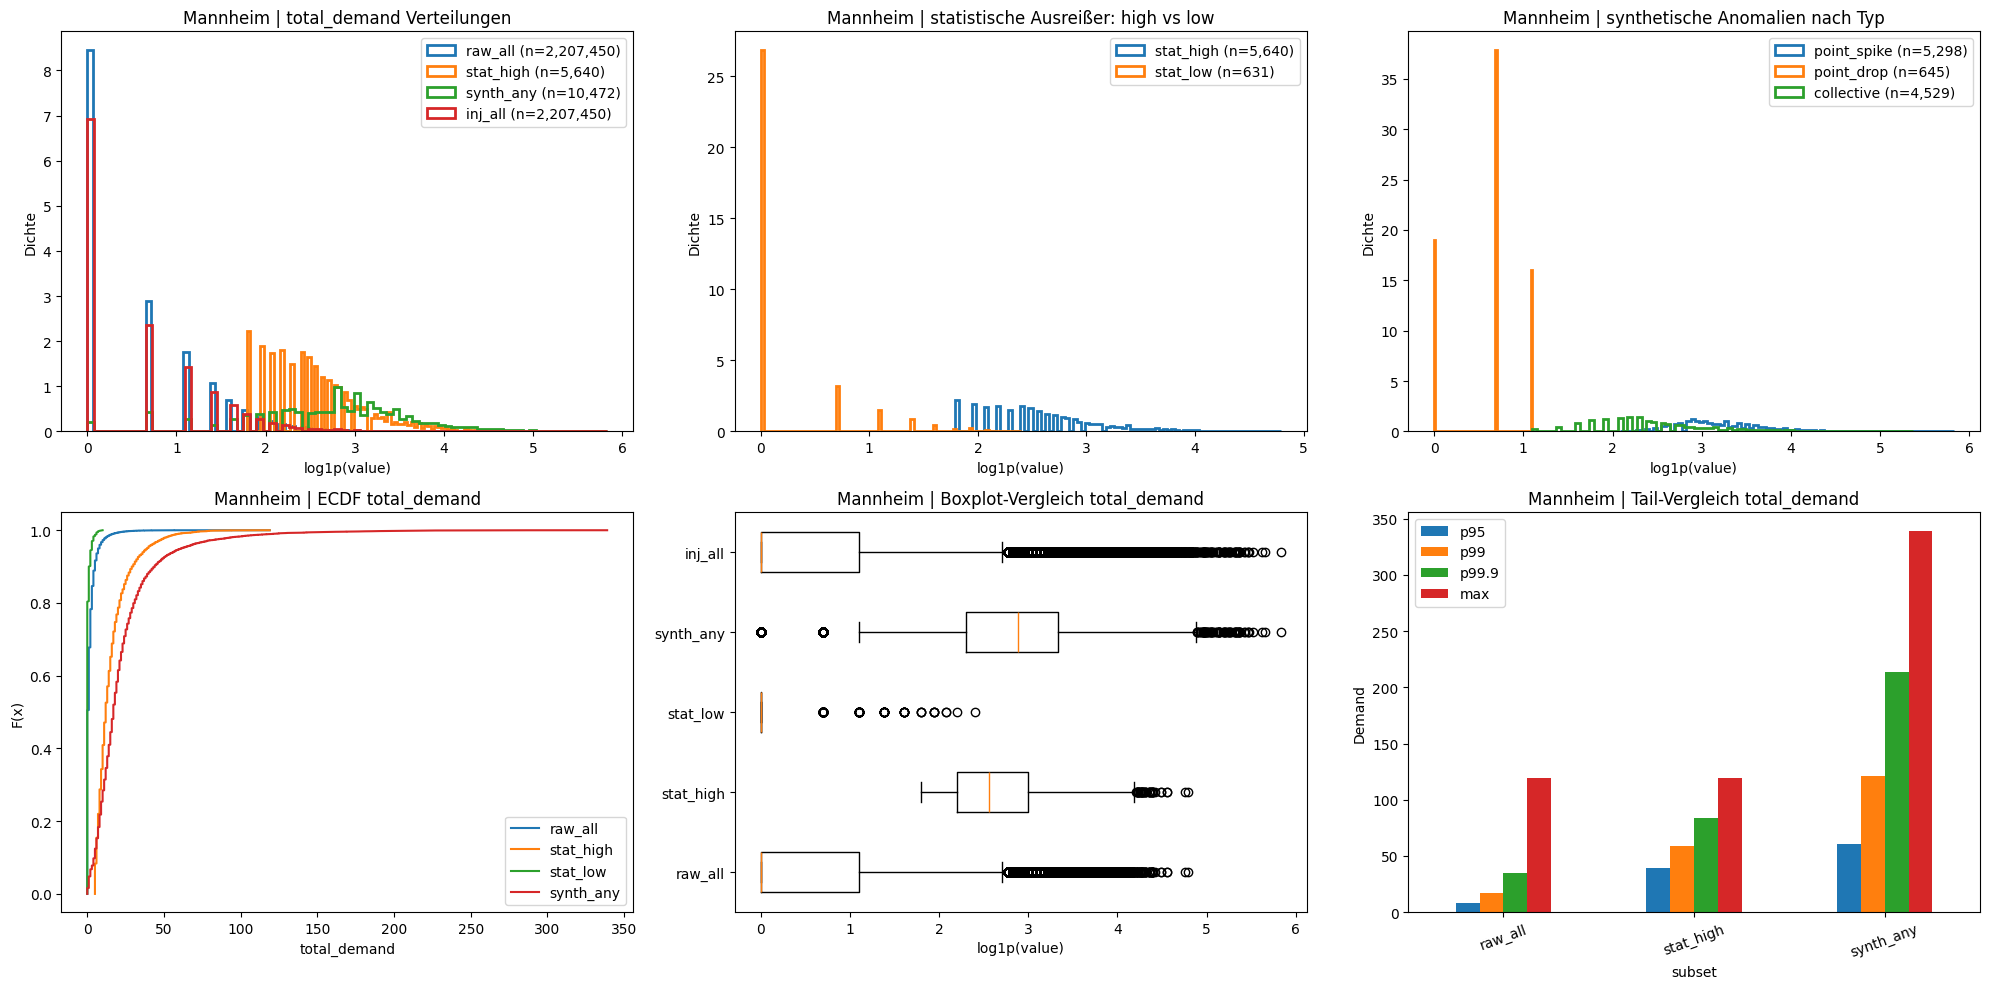

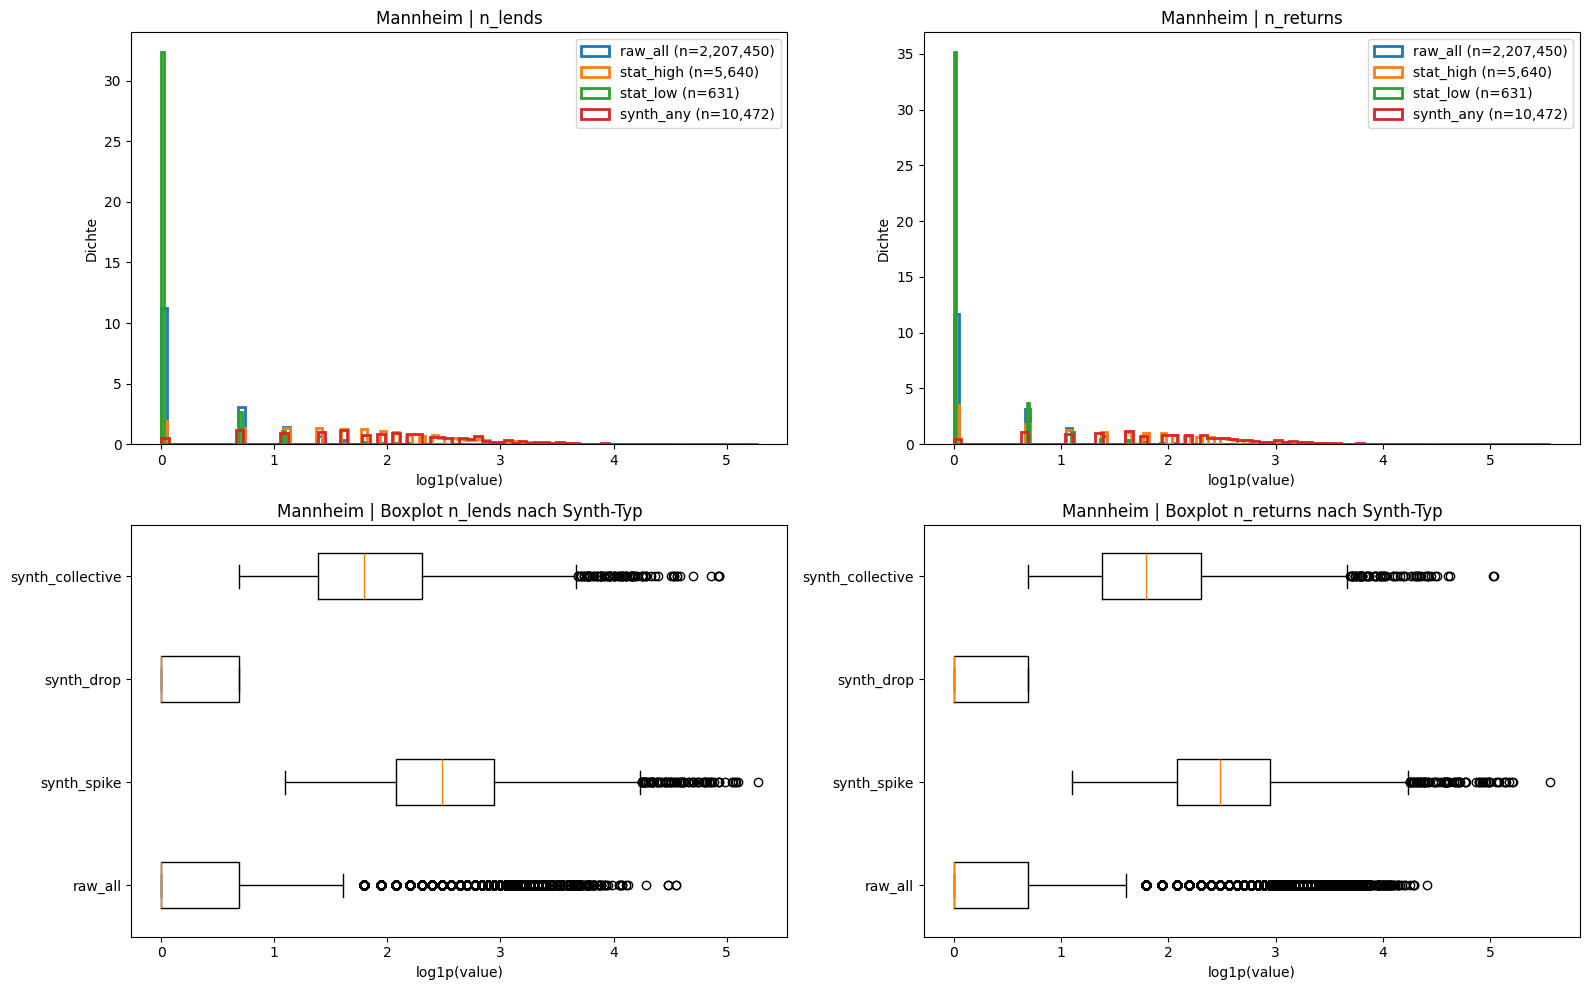


=== Mannheim | Split-Check VAL vs TEST ===


,split,n_rows,n_synth,synth_rate,median_total_demand_all,median_total_demand_synth
0,VAL,340340,5074,1.0,1.0,17.0
1,TEST,408388,5398,1.0,0.0,17.0


In [18]:
# ============================================================
# Distribution Audit:
# Rohdaten vs. statistische Ausreißer vs. synthetische Anomalien
# Voraussetzung:
#   - city_raw vorhanden
#   - city_injected vorhanden
#   - matplotlib / pandas / numpy importiert
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Konfiguration
# -----------------------------
AUDIT_CITY = "Mannheim"   # <- Stadt hier anpassen
USE_LOG_X = True          # log1p-Skalierung für Demand-Plots
SHOW_COMPONENTS = True    # n_lends / n_returns separat mit prüfen
TOP_Q = 0.999            # obere Quantilsgrenze für Zusatzkennzahlen
BINS = 80

# -----------------------------
# Helper
# -----------------------------
def _safe_series(df, col):
    if col not in df.columns:
        return pd.Series(dtype=float)
    s = pd.to_numeric(df[col], errors="coerce")
    return s[np.isfinite(s)]

def _desc(s, name):
    s = pd.Series(s).dropna()
    if len(s) == 0:
        return {
            "subset": name, "n": 0, "mean": np.nan, "std": np.nan,
            "min": np.nan, "p50": np.nan, "p90": np.nan, "p95": np.nan,
            "p99": np.nan, "p99.9": np.nan, "max": np.nan
        }
    return {
        "subset": name,
        "n": len(s),
        "mean": s.mean(),
        "std": s.std(),
        "min": s.min(),
        "p50": s.quantile(0.50),
        "p90": s.quantile(0.90),
        "p95": s.quantile(0.95),
        "p99": s.quantile(0.99),
        "p99.9": s.quantile(0.999),
        "max": s.max(),
    }

def _print_table(title, rows):
    print(f"\n{title}")
    display(pd.DataFrame(rows).round(3))

def _ecdf(ax, values, label):
    values = pd.Series(values).dropna().sort_values().to_numpy()
    if len(values) == 0:
        return
    y = np.arange(1, len(values) + 1) / len(values)
    ax.plot(values, y, label=label)

def _plot_hist_compare(ax, series_dict, title, log_x=True, bins=80):
    plotted = False
    for label, s in series_dict.items():
        s = pd.Series(s).dropna()
        if len(s) == 0:
            continue
        x = np.log1p(s) if log_x else s
        ax.hist(x, bins=bins, density=True, histtype="step", linewidth=2, label=f"{label} (n={len(s):,})")
        plotted = True
    ax.set_title(title)
    ax.set_ylabel("Dichte")
    ax.set_xlabel("log1p(value)" if log_x else "value")
    if plotted:
        ax.legend()

def _plot_box_compare(ax, series_dict, title, log_x=True):
    labels, data = [], []
    for label, s in series_dict.items():
        s = pd.Series(s).dropna()
        if len(s) == 0:
            continue
        x = np.log1p(s) if log_x else s
        labels.append(label)
        data.append(x)
    if len(data) == 0:
        ax.set_title(title + " (keine Daten)")
        return
    ax.boxplot(data, vert=False, labels=labels, showfliers=True)
    ax.set_title(title)
    ax.set_xlabel("log1p(value)" if log_x else "value")

def build_distribution_audit(city, city_raw, city_injected, use_log_x=True, show_components=True, bins=80, top_q=0.999):
    if city not in city_raw:
        raise ValueError(f"{city} nicht in city_raw vorhanden.")
    if city not in city_injected:
        raise ValueError(f"{city} nicht in city_injected vorhanden.")

    raw_df, profile, train_end, val_end = city_raw[city]
    inj_df = city_injected[city].copy()

    raw_df = raw_df.copy()

    # -----------------------------
    # Teilmengen definieren
    # -----------------------------
    raw_all = raw_df.copy()

    if "label_eval" in raw_all.columns:
        stat_high = raw_all[raw_all["label_eval"] == "anomal_high"].copy()
        stat_low  = raw_all[raw_all["label_eval"] == "anomal_low"].copy()
        stat_any  = raw_all[raw_all["label_eval"].isin(["anomal_high", "anomal_low"])].copy()
    else:
        stat_high = raw_all.iloc[0:0].copy()
        stat_low  = raw_all.iloc[0:0].copy()
        stat_any  = raw_all.iloc[0:0].copy()

    if "synth_label" in inj_df.columns:
        synth_any = inj_df[inj_df["synth_label"] == 1].copy()
    else:
        synth_any = inj_df.iloc[0:0].copy()

    if "synth_type" in synth_any.columns:
        synth_spike = synth_any[synth_any["synth_type"] == "point_spike"].copy()
        synth_drop  = synth_any[synth_any["synth_type"] == "point_drop"].copy()
        synth_coll  = synth_any[synth_any["synth_type"] == "collective"].copy()
    else:
        synth_spike = synth_any.iloc[0:0].copy()
        synth_drop  = synth_any.iloc[0:0].copy()
        synth_coll  = synth_any.iloc[0:0].copy()

    inj_all = inj_df.copy()

    # -----------------------------
    # Kennzahlen total_demand
    # -----------------------------
    subsets = {
        "raw_all": raw_all,
        "stat_high": stat_high,
        "stat_low": stat_low,
        "stat_any": stat_any,
        "synth_any": synth_any,
        "synth_spike": synth_spike,
        "synth_drop": synth_drop,
        "synth_collective": synth_coll,
        "inj_all": inj_all,
    }

    rows_total = []
    for name, df in subsets.items():
        rows_total.append(_desc(_safe_series(df, "total_demand"), name))
    _print_table(f"=== {city} | Verteilung total_demand ===", rows_total)

    if show_components:
        rows_lends = []
        rows_returns = []
        for name, df in subsets.items():
            rows_lends.append(_desc(_safe_series(df, "n_lends"), name))
            rows_returns.append(_desc(_safe_series(df, "n_returns"), name))
        _print_table(f"=== {city} | Verteilung n_lends ===", rows_lends)
        _print_table(f"=== {city} | Verteilung n_returns ===", rows_returns)

    # -----------------------------
    # Realismus-Kennzahlen
    # -----------------------------
    raw_td = _safe_series(raw_all, "total_demand")
    synth_td = _safe_series(synth_any, "total_demand")
    stat_high_td = _safe_series(stat_high, "total_demand")
    stat_low_td = _safe_series(stat_low, "total_demand")

    realism = {}

    if len(raw_td) > 0 and len(synth_td) > 0:
        raw_p95 = raw_td.quantile(0.95)
        raw_p99 = raw_td.quantile(0.99)
        raw_top = raw_td.quantile(top_q)
        raw_max = raw_td.max()

        realism = {
            "raw_p95": raw_p95,
            "raw_p99": raw_p99,
            f"raw_p{top_q*100:.1f}": raw_top,
            "raw_max": raw_max,
            "share_synth_above_raw_p95": (synth_td > raw_p95).mean(),
            "share_synth_above_raw_p99": (synth_td > raw_p99).mean(),
            f"share_synth_above_raw_p{top_q*100:.1f}": (synth_td > raw_top).mean(),
            "share_synth_above_raw_max": (synth_td > raw_max).mean(),
            "median_ratio_synth_to_raw_p99": synth_td.median() / raw_p99 if raw_p99 > 0 else np.nan,
            "max_ratio_synth_to_raw_max": synth_td.max() / raw_max if raw_max > 0 else np.nan,
        }

        # Für Drops:
        realism["share_synth_drop_eq_zero"] = ( _safe_series(synth_drop, "total_demand") == 0 ).mean() if len(synth_drop) > 0 else np.nan
        realism["share_stat_low_eq_zero"] = (stat_low_td == 0).mean() if len(stat_low_td) > 0 else np.nan

    print(f"\n=== {city} | Realismus-Checks synthetische Anomalien ===")
    display(pd.DataFrame([realism]).round(4))

    # -----------------------------
    # Relative Abweichung zum Original bei Injection
    # -----------------------------
    if {"original_n_lends", "original_n_returns"}.issubset(inj_df.columns):
        inj_df["original_total_demand"] = inj_df["original_n_lends"].fillna(0) + inj_df["original_n_returns"].fillna(0)
        synth_cmp = inj_df[inj_df.get("synth_label", 0) == 1].copy()
        if len(synth_cmp) > 0:
            denom = synth_cmp["original_total_demand"].replace(0, np.nan)
            synth_cmp["relative_change_total"] = (synth_cmp["total_demand"] - synth_cmp["original_total_demand"]) / denom
            synth_cmp["absolute_change_total"] = synth_cmp["total_demand"] - synth_cmp["original_total_demand"]

            rows_change = []
            for t, g in synth_cmp.groupby("synth_type"):
                rows_change.append({
                    "synth_type": t,
                    "n": len(g),
                    "orig_p50": g["original_total_demand"].median(),
                    "new_p50": g["total_demand"].median(),
                    "abs_change_p50": g["absolute_change_total"].median(),
                    "abs_change_p95": g["absolute_change_total"].quantile(0.95),
                    "rel_change_p50": g["relative_change_total"].median(),
                    "rel_change_p95": g["relative_change_total"].quantile(0.95),
                })
            _print_table(f"=== {city} | Veränderung durch Injection (gegen Original) ===", rows_change)

    # -----------------------------
    # Plotting total_demand
    # -----------------------------
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))

    _plot_hist_compare(
        axes[0, 0],
        {
            "raw_all": raw_td,
            "stat_high": stat_high_td,
            "synth_any": synth_td,
            "inj_all": _safe_series(inj_all, "total_demand")
        },
        title=f"{city} | total_demand Verteilungen",
        log_x=use_log_x,
        bins=bins
    )

    _plot_hist_compare(
        axes[0, 1],
        {
            "stat_high": stat_high_td,
            "stat_low": stat_low_td,
        },
        title=f"{city} | statistische Ausreißer: high vs low",
        log_x=use_log_x,
        bins=bins
    )

    _plot_hist_compare(
        axes[0, 2],
        {
            "point_spike": _safe_series(synth_spike, "total_demand"),
            "point_drop": _safe_series(synth_drop, "total_demand"),
            "collective": _safe_series(synth_coll, "total_demand"),
        },
        title=f"{city} | synthetische Anomalien nach Typ",
        log_x=use_log_x,
        bins=bins
    )

    # ECDF
    ax = axes[1, 0]
    _ecdf(ax, raw_td, "raw_all")
    _ecdf(ax, stat_high_td, "stat_high")
    _ecdf(ax, stat_low_td, "stat_low")
    _ecdf(ax, synth_td, "synth_any")
    ax.set_title(f"{city} | ECDF total_demand")
    ax.set_xlabel("total_demand")
    ax.set_ylabel("F(x)")
    ax.legend()

    # Boxplots
    _plot_box_compare(
        axes[1, 1],
        {
            "raw_all": raw_td,
            "stat_high": stat_high_td,
            "stat_low": stat_low_td,
            "synth_any": synth_td,
            "inj_all": _safe_series(inj_all, "total_demand"),
        },
        title=f"{city} | Boxplot-Vergleich total_demand",
        log_x=use_log_x
    )

    # Tail-Vergleich
    ax = axes[1, 2]
    tail_sets = {
        "raw_all": raw_td,
        "stat_high": stat_high_td,
        "synth_any": synth_td,
    }
    tail_rows = []
    for name, s in tail_sets.items():
        s = pd.Series(s).dropna()
        if len(s) == 0:
            continue
        tail_rows.append([
            name,
            s.quantile(0.95),
            s.quantile(0.99),
            s.quantile(0.999),
            s.max()
        ])
    if len(tail_rows) > 0:
        tail_df = pd.DataFrame(tail_rows, columns=["subset", "p95", "p99", "p99.9", "max"]).set_index("subset")
        tail_df.plot(kind="bar", ax=ax)
        ax.set_title(f"{city} | Tail-Vergleich total_demand")
        ax.set_ylabel("Demand")
        ax.tick_params(axis="x", rotation=20)
    else:
        ax.set_title("Keine Tail-Daten")

    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Komponentenplots
    # -----------------------------
    if show_components:
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))

        _plot_hist_compare(
            axes[0, 0],
            {
                "raw_all": _safe_series(raw_all, "n_lends"),
                "stat_high": _safe_series(stat_high, "n_lends"),
                "stat_low": _safe_series(stat_low, "n_lends"),
                "synth_any": _safe_series(synth_any, "n_lends"),
            },
            title=f"{city} | n_lends",
            log_x=use_log_x,
            bins=bins
        )

        _plot_hist_compare(
            axes[0, 1],
            {
                "raw_all": _safe_series(raw_all, "n_returns"),
                "stat_high": _safe_series(stat_high, "n_returns"),
                "stat_low": _safe_series(stat_low, "n_returns"),
                "synth_any": _safe_series(synth_any, "n_returns"),
            },
            title=f"{city} | n_returns",
            log_x=use_log_x,
            bins=bins
        )

        _plot_box_compare(
            axes[1, 0],
            {
                "raw_all": _safe_series(raw_all, "n_lends"),
                "synth_spike": _safe_series(synth_spike, "n_lends"),
                "synth_drop": _safe_series(synth_drop, "n_lends"),
                "synth_collective": _safe_series(synth_coll, "n_lends"),
            },
            title=f"{city} | Boxplot n_lends nach Synth-Typ",
            log_x=use_log_x
        )

        _plot_box_compare(
            axes[1, 1],
            {
                "raw_all": _safe_series(raw_all, "n_returns"),
                "synth_spike": _safe_series(synth_spike, "n_returns"),
                "synth_drop": _safe_series(synth_drop, "n_returns"),
                "synth_collective": _safe_series(synth_coll, "n_returns"),
            },
            title=f"{city} | Boxplot n_returns nach Synth-Typ",
            log_x=use_log_x
        )

        plt.tight_layout()
        plt.show()

    # -----------------------------
    # Optional: Split VAL / TEST
    # -----------------------------
    if "hour_ts" in inj_df.columns:
        val_mask = (inj_df["hour_ts"] >= train_end) & (inj_df["hour_ts"] < val_end)
        test_mask = inj_df["hour_ts"] >= val_end

        split_rows = []
        for split_name, mask in [("VAL", val_mask), ("TEST", test_mask)]:
            g = inj_df.loc[mask]
            s = g[g.get("synth_label", 0) == 1]
            split_rows.append({
                "split": split_name,
                "n_rows": len(g),
                "n_synth": int(s.get("synth_label", pd.Series(dtype=int)).sum()) if len(s) > 0 else 0,
                "synth_rate": s.get("synth_label", pd.Series(dtype=int)).mean() if len(s) > 0 else 0.0,
                "median_total_demand_all": g["total_demand"].median() if len(g) > 0 else np.nan,
                "median_total_demand_synth": s["total_demand"].median() if len(s) > 0 else np.nan,
            })
        _print_table(f"=== {city} | Split-Check VAL vs TEST ===", split_rows)

# -----------------------------
# Run
# -----------------------------
build_distribution_audit(
    city=AUDIT_CITY,
    city_raw=city_raw,
    city_injected=city_injected,
    use_log_x=USE_LOG_X,
    show_components=SHOW_COMPONENTS,
    bins=BINS,
    top_q=TOP_Q
)

,Gruppe,n,Ø Demand,Median,p95,p99,Max
0,Raw All,2207450,1.77,0.0,8.0,17.00,119
1,Statistic High,5640,15.51,12.0,39.0,59.00,119
2,Statistic Low,631,0.42,0.0,3.0,6.00,10
3,Synthetic Spike,5298,30.66,23.0,77.0,144.00,339
4,Synthetic Drop,645,0.96,1.0,2.0,2.00,2
5,Synthetic Collective,4529,15.84,11.0,46.0,88.72,213


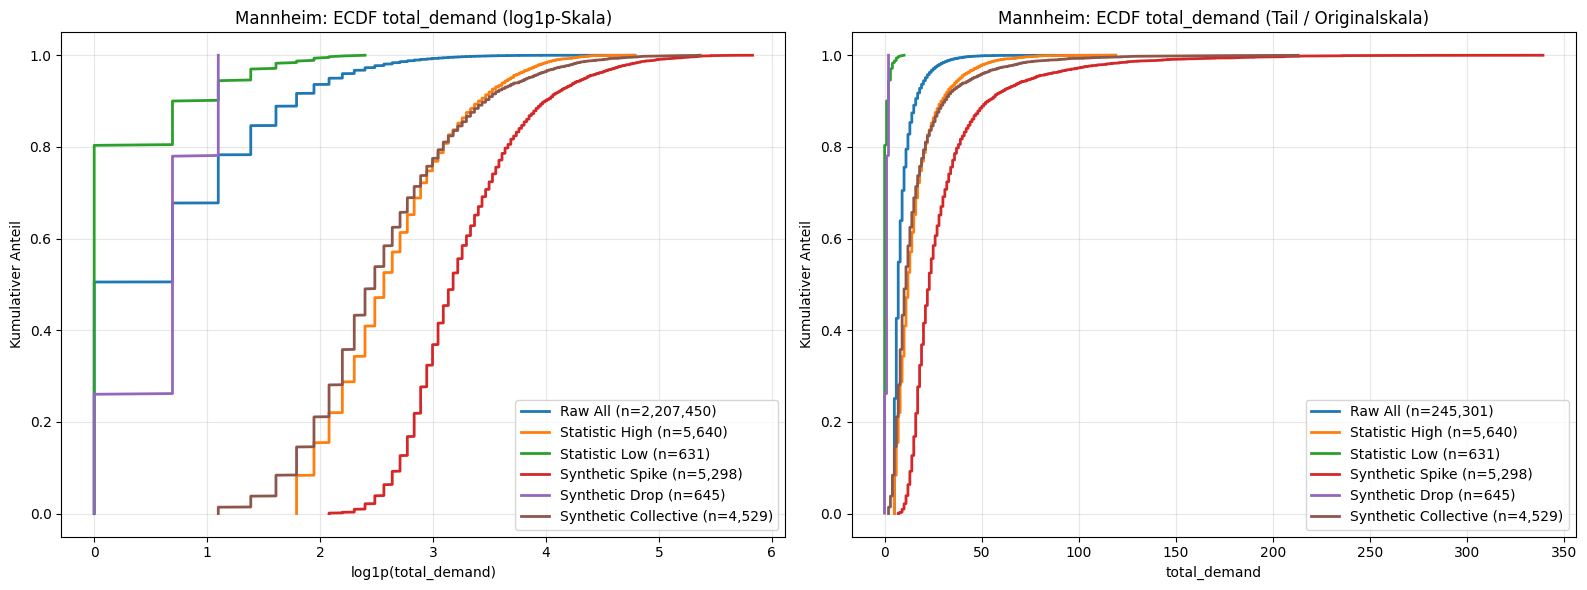

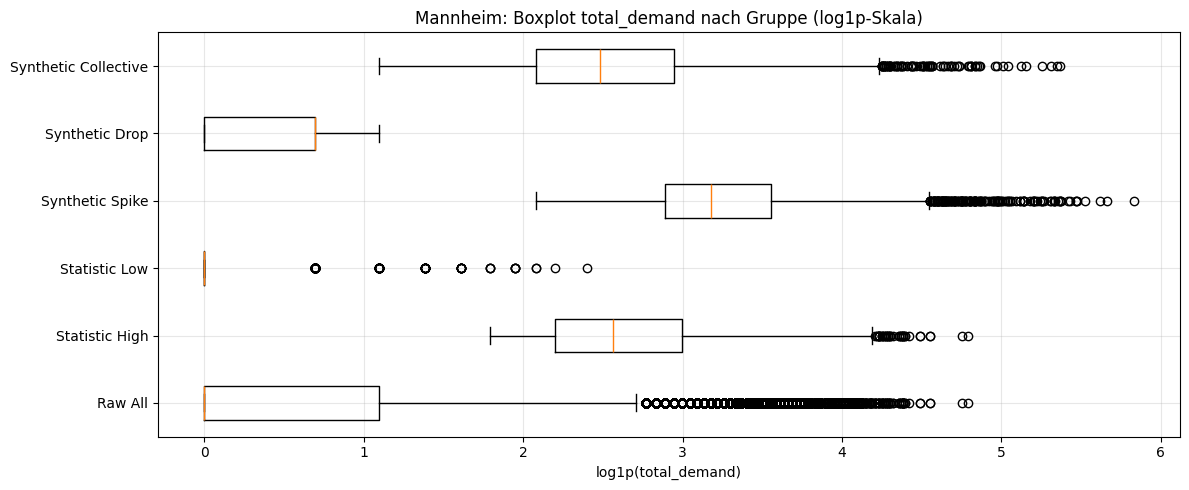

In [22]:
# ============================================================
# Verteilungsvergleich total_demand:
# Raw All vs Statistic High/Low vs Synthetic Spike/Drop/Collective
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CITY = "Mannheim"   # <- anpassen

# ------------------------------------------------------------
# Daten holen
# ------------------------------------------------------------
raw_df, profile, train_end, val_end = city_raw[CITY]
inj_df = city_injected[CITY].copy()
raw_df = raw_df.copy()

def get_numeric(df, mask, col="total_demand"):
    if col not in df.columns:
        return pd.Series(dtype=float)
    s = pd.to_numeric(df.loc[mask, col], errors="coerce")
    return s[np.isfinite(s)]

raw_all = get_numeric(raw_df, raw_df.index == raw_df.index, "total_demand")

if "label_eval" in raw_df.columns:
    stat_high = get_numeric(raw_df, raw_df["label_eval"] == "anomal_high")
    stat_low  = get_numeric(raw_df, raw_df["label_eval"] == "anomal_low")
else:
    stat_high = pd.Series(dtype=float)
    stat_low  = pd.Series(dtype=float)

if {"synth_label", "synth_type"}.issubset(inj_df.columns):
    synth_spike = get_numeric(inj_df, (inj_df["synth_label"] == 1) & (inj_df["synth_type"] == "point_spike"))
    synth_drop  = get_numeric(inj_df, (inj_df["synth_label"] == 1) & (inj_df["synth_type"] == "point_drop"))
    synth_coll  = get_numeric(inj_df, (inj_df["synth_label"] == 1) & (inj_df["synth_type"] == "collective"))
else:
    synth_spike = pd.Series(dtype=float)
    synth_drop  = pd.Series(dtype=float)
    synth_coll  = pd.Series(dtype=float)

series_dict = {
    "Raw All": raw_all,
    "Statistic High": stat_high,
    "Statistic Low": stat_low,
    "Synthetic Spike": synth_spike,
    "Synthetic Drop": synth_drop,
    "Synthetic Collective": synth_coll,
}

# ------------------------------------------------------------
# Kompakte Tabelle
# ------------------------------------------------------------
def summarize(name, s):
    s = pd.Series(s).dropna()
    if len(s) == 0:
        return {
            "Gruppe": name,
            "n": 0,
            "Ø Demand": np.nan,
            "Median": np.nan,
            "p95": np.nan,
            "p99": np.nan,
            "Max": np.nan,
        }
    return {
        "Gruppe": name,
        "n": len(s),
        "Ø Demand": round(s.mean(), 2),
        "Median": round(s.median(), 2),
        "p95": round(s.quantile(0.95), 2),
        "p99": round(s.quantile(0.99), 2),
        "Max": round(s.max(), 2),
    }

summary_df = pd.DataFrame([summarize(name, s) for name, s in series_dict.items()])
display(summary_df)

# ------------------------------------------------------------
# Plot: ECDF + Zoom-ECDF
# ------------------------------------------------------------
def plot_ecdf(ax, s, label, log_x=False):
    s = pd.Series(s).dropna().sort_values().to_numpy()
    if len(s) == 0:
        return
    y = np.arange(1, len(s) + 1) / len(s)
    x = np.log1p(s) if log_x else s
    ax.plot(x, y, linewidth=2, label=f"{label} (n={len(s):,})")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Links: volle Verteilung
for name, s in series_dict.items():
    plot_ecdf(axes[0], s, name, log_x=True)

axes[0].set_title(f"{CITY}: ECDF total_demand (log1p-Skala)")
axes[0].set_xlabel("log1p(total_demand)")
axes[0].set_ylabel("Kumulativer Anteil")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Rechts: Zoom auf Tail / Originalskala
tail_dict = {
    "Raw All": raw_all[raw_all >= raw_all.quantile(0.90)],
    "Statistic High": stat_high,
    "Statistic Low": stat_low,
    "Synthetic Spike": synth_spike,
    "Synthetic Drop": synth_drop,
    "Synthetic Collective": synth_coll,
}
for name, s in tail_dict.items():
    plot_ecdf(axes[1], s, name, log_x=False)

axes[1].set_title(f"{CITY}: ECDF total_demand (Tail / Originalskala)")
axes[1].set_xlabel("total_demand")
axes[1].set_ylabel("Kumulativer Anteil")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Optional: zusätzlich Boxplot auf log1p-Skala
# ------------------------------------------------------------
labels = []
data = []
for name, s in series_dict.items():
    s = pd.Series(s).dropna()
    if len(s) > 0:
        labels.append(name)
        data.append(np.log1p(s))

plt.figure(figsize=(12, 5))
plt.boxplot(data, vert=False, labels=labels, showfliers=True)
plt.title(f"{CITY}: Boxplot total_demand nach Gruppe (log1p-Skala)")
plt.xlabel("log1p(total_demand)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

,Gruppe,n,Ø Demand,Median,p95,p99,Max
0,Raw All,1676943,2.13,1.0,9.0,19.00,105
1,Statistic High,4921,15.82,13.0,36.0,58.00,105
2,Statistic Low,679,0.44,0.0,2.0,5.22,12
3,Synthetic Spike,3914,33.67,23.5,90.0,161.74,378
4,Synthetic Drop,570,0.93,1.0,2.0,2.00,2
5,Synthetic Collective,3444,18.21,12.0,54.0,108.00,183


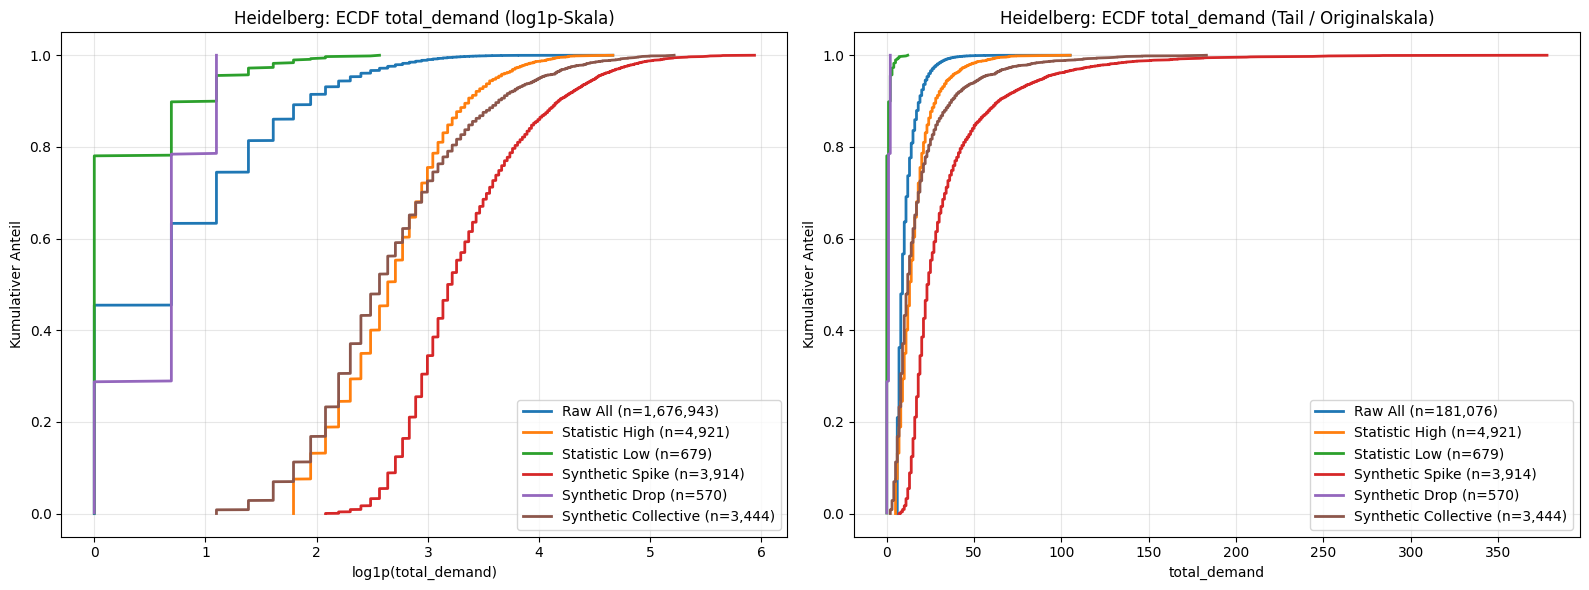

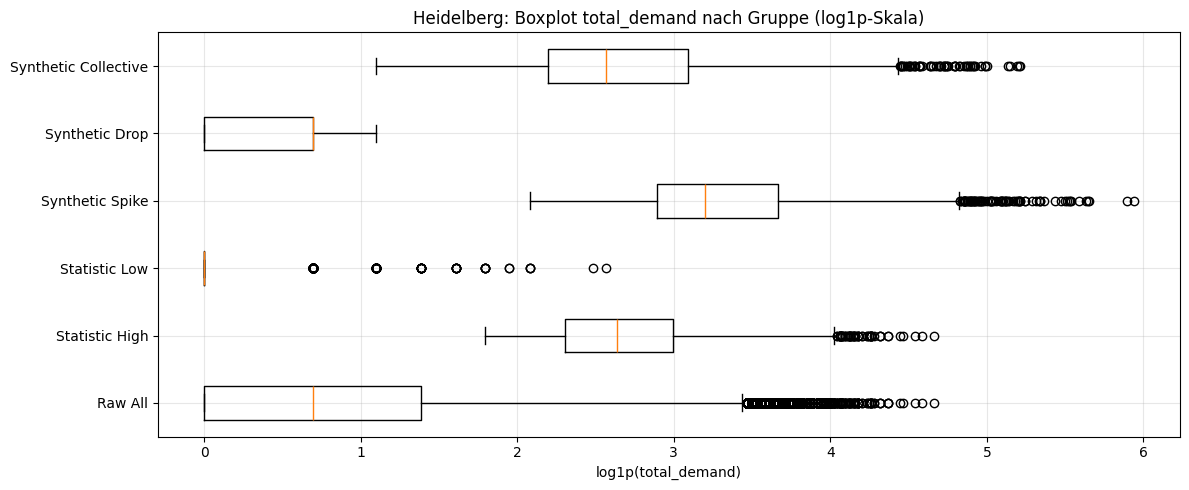

In [23]:
# ============================================================
# Verteilungsvergleich total_demand:
# Raw All vs Statistic High/Low vs Synthetic Spike/Drop/Collective
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CITY = "Heidelberg"   # <- anpassen

# ------------------------------------------------------------
# Daten holen
# ------------------------------------------------------------
raw_df, profile, train_end, val_end = city_raw[CITY]
inj_df = city_injected[CITY].copy()
raw_df = raw_df.copy()

def get_numeric(df, mask, col="total_demand"):
    if col not in df.columns:
        return pd.Series(dtype=float)
    s = pd.to_numeric(df.loc[mask, col], errors="coerce")
    return s[np.isfinite(s)]

raw_all = get_numeric(raw_df, raw_df.index == raw_df.index, "total_demand")

if "label_eval" in raw_df.columns:
    stat_high = get_numeric(raw_df, raw_df["label_eval"] == "anomal_high")
    stat_low  = get_numeric(raw_df, raw_df["label_eval"] == "anomal_low")
else:
    stat_high = pd.Series(dtype=float)
    stat_low  = pd.Series(dtype=float)

if {"synth_label", "synth_type"}.issubset(inj_df.columns):
    synth_spike = get_numeric(inj_df, (inj_df["synth_label"] == 1) & (inj_df["synth_type"] == "point_spike"))
    synth_drop  = get_numeric(inj_df, (inj_df["synth_label"] == 1) & (inj_df["synth_type"] == "point_drop"))
    synth_coll  = get_numeric(inj_df, (inj_df["synth_label"] == 1) & (inj_df["synth_type"] == "collective"))
else:
    synth_spike = pd.Series(dtype=float)
    synth_drop  = pd.Series(dtype=float)
    synth_coll  = pd.Series(dtype=float)

series_dict = {
    "Raw All": raw_all,
    "Statistic High": stat_high,
    "Statistic Low": stat_low,
    "Synthetic Spike": synth_spike,
    "Synthetic Drop": synth_drop,
    "Synthetic Collective": synth_coll,
}

# ------------------------------------------------------------
# Kompakte Tabelle
# ------------------------------------------------------------
def summarize(name, s):
    s = pd.Series(s).dropna()
    if len(s) == 0:
        return {
            "Gruppe": name,
            "n": 0,
            "Ø Demand": np.nan,
            "Median": np.nan,
            "p95": np.nan,
            "p99": np.nan,
            "Max": np.nan,
        }
    return {
        "Gruppe": name,
        "n": len(s),
        "Ø Demand": round(s.mean(), 2),
        "Median": round(s.median(), 2),
        "p95": round(s.quantile(0.95), 2),
        "p99": round(s.quantile(0.99), 2),
        "Max": round(s.max(), 2),
    }

summary_df = pd.DataFrame([summarize(name, s) for name, s in series_dict.items()])
display(summary_df)

# ------------------------------------------------------------
# Plot: ECDF + Zoom-ECDF
# ------------------------------------------------------------
def plot_ecdf(ax, s, label, log_x=False):
    s = pd.Series(s).dropna().sort_values().to_numpy()
    if len(s) == 0:
        return
    y = np.arange(1, len(s) + 1) / len(s)
    x = np.log1p(s) if log_x else s
    ax.plot(x, y, linewidth=2, label=f"{label} (n={len(s):,})")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Links: volle Verteilung
for name, s in series_dict.items():
    plot_ecdf(axes[0], s, name, log_x=True)

axes[0].set_title(f"{CITY}: ECDF total_demand (log1p-Skala)")
axes[0].set_xlabel("log1p(total_demand)")
axes[0].set_ylabel("Kumulativer Anteil")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Rechts: Zoom auf Tail / Originalskala
tail_dict = {
    "Raw All": raw_all[raw_all >= raw_all.quantile(0.90)],
    "Statistic High": stat_high,
    "Statistic Low": stat_low,
    "Synthetic Spike": synth_spike,
    "Synthetic Drop": synth_drop,
    "Synthetic Collective": synth_coll,
}
for name, s in tail_dict.items():
    plot_ecdf(axes[1], s, name, log_x=False)

axes[1].set_title(f"{CITY}: ECDF total_demand (Tail / Originalskala)")
axes[1].set_xlabel("total_demand")
axes[1].set_ylabel("Kumulativer Anteil")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Optional: zusätzlich Boxplot auf log1p-Skala
# ------------------------------------------------------------
labels = []
data = []
for name, s in series_dict.items():
    s = pd.Series(s).dropna()
    if len(s) > 0:
        labels.append(name)
        data.append(np.log1p(s))

plt.figure(figsize=(12, 5))
plt.boxplot(data, vert=False, labels=labels, showfliers=True)
plt.title(f"{CITY}: Boxplot total_demand nach Gruppe (log1p-Skala)")
plt.xlabel("log1p(total_demand)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

,Gruppe,n,Ø Demand,Median,p95,p99,Max
0,Raw All,853770,1.58,0.0,7.0,15.00,238
1,Statistic High,3151,16.61,12.0,37.0,93.00,238
2,Statistic Low,226,0.31,0.0,2.0,4.00,5
3,Synthetic Spike,1929,26.34,21.0,58.0,116.88,231
4,Synthetic Drop,139,0.93,1.0,2.0,2.00,2
5,Synthetic Collective,1740,13.85,10.0,36.0,85.00,131


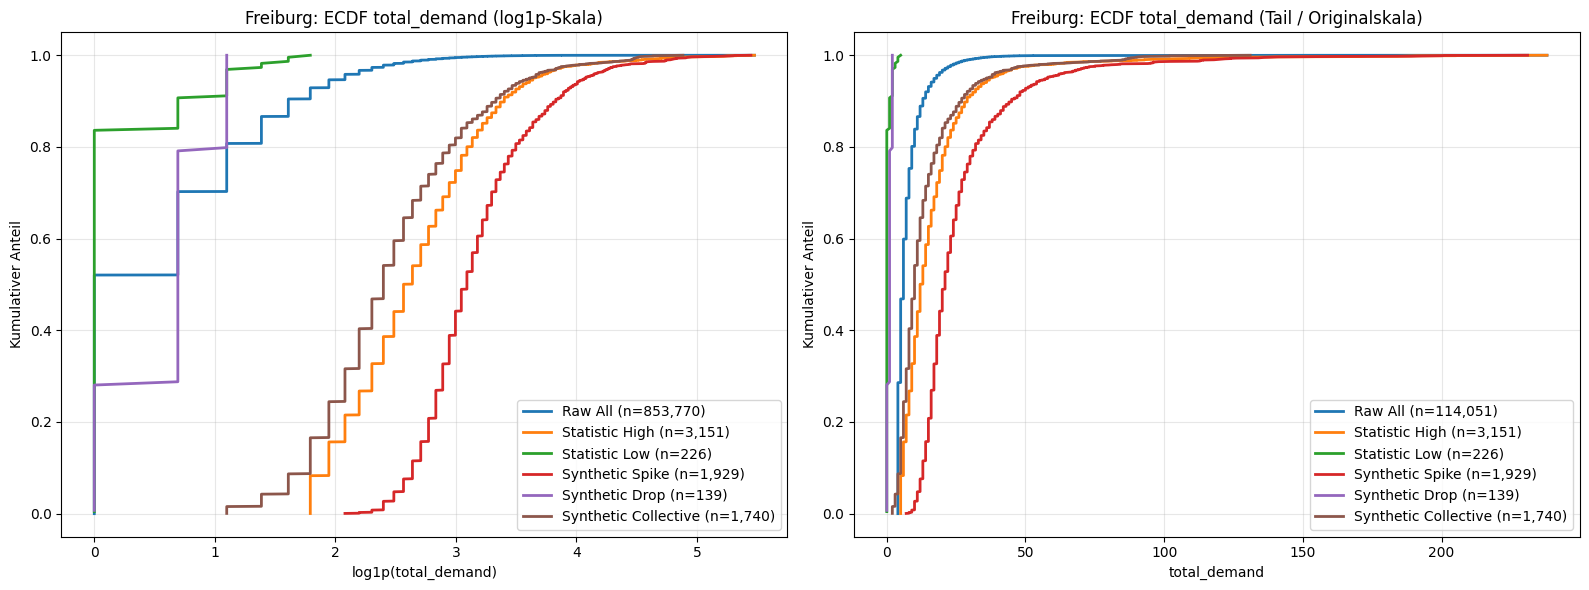

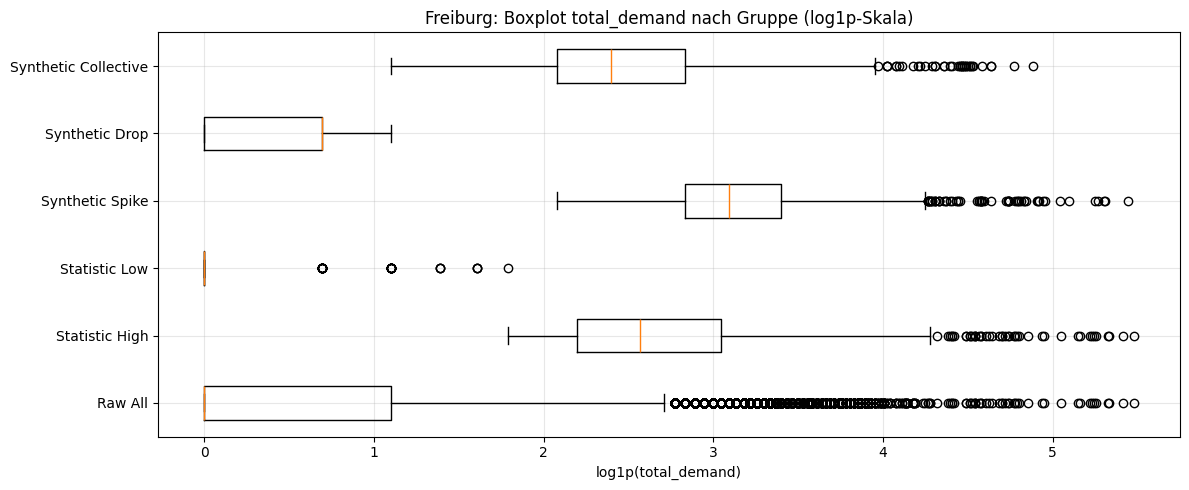

In [24]:
# ============================================================
# Verteilungsvergleich total_demand:
# Raw All vs Statistic High/Low vs Synthetic Spike/Drop/Collective
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CITY = "Freiburg"   # <- anpassen

# ------------------------------------------------------------
# Daten holen
# ------------------------------------------------------------
raw_df, profile, train_end, val_end = city_raw[CITY]
inj_df = city_injected[CITY].copy()
raw_df = raw_df.copy()

def get_numeric(df, mask, col="total_demand"):
    if col not in df.columns:
        return pd.Series(dtype=float)
    s = pd.to_numeric(df.loc[mask, col], errors="coerce")
    return s[np.isfinite(s)]

raw_all = get_numeric(raw_df, raw_df.index == raw_df.index, "total_demand")

if "label_eval" in raw_df.columns:
    stat_high = get_numeric(raw_df, raw_df["label_eval"] == "anomal_high")
    stat_low  = get_numeric(raw_df, raw_df["label_eval"] == "anomal_low")
else:
    stat_high = pd.Series(dtype=float)
    stat_low  = pd.Series(dtype=float)

if {"synth_label", "synth_type"}.issubset(inj_df.columns):
    synth_spike = get_numeric(inj_df, (inj_df["synth_label"] == 1) & (inj_df["synth_type"] == "point_spike"))
    synth_drop  = get_numeric(inj_df, (inj_df["synth_label"] == 1) & (inj_df["synth_type"] == "point_drop"))
    synth_coll  = get_numeric(inj_df, (inj_df["synth_label"] == 1) & (inj_df["synth_type"] == "collective"))
else:
    synth_spike = pd.Series(dtype=float)
    synth_drop  = pd.Series(dtype=float)
    synth_coll  = pd.Series(dtype=float)

series_dict = {
    "Raw All": raw_all,
    "Statistic High": stat_high,
    "Statistic Low": stat_low,
    "Synthetic Spike": synth_spike,
    "Synthetic Drop": synth_drop,
    "Synthetic Collective": synth_coll,
}

# ------------------------------------------------------------
# Kompakte Tabelle
# ------------------------------------------------------------
def summarize(name, s):
    s = pd.Series(s).dropna()
    if len(s) == 0:
        return {
            "Gruppe": name,
            "n": 0,
            "Ø Demand": np.nan,
            "Median": np.nan,
            "p95": np.nan,
            "p99": np.nan,
            "Max": np.nan,
        }
    return {
        "Gruppe": name,
        "n": len(s),
        "Ø Demand": round(s.mean(), 2),
        "Median": round(s.median(), 2),
        "p95": round(s.quantile(0.95), 2),
        "p99": round(s.quantile(0.99), 2),
        "Max": round(s.max(), 2),
    }

summary_df = pd.DataFrame([summarize(name, s) for name, s in series_dict.items()])
display(summary_df)

# ------------------------------------------------------------
# Plot: ECDF + Zoom-ECDF
# ------------------------------------------------------------
def plot_ecdf(ax, s, label, log_x=False):
    s = pd.Series(s).dropna().sort_values().to_numpy()
    if len(s) == 0:
        return
    y = np.arange(1, len(s) + 1) / len(s)
    x = np.log1p(s) if log_x else s
    ax.plot(x, y, linewidth=2, label=f"{label} (n={len(s):,})")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Links: volle Verteilung
for name, s in series_dict.items():
    plot_ecdf(axes[0], s, name, log_x=True)

axes[0].set_title(f"{CITY}: ECDF total_demand (log1p-Skala)")
axes[0].set_xlabel("log1p(total_demand)")
axes[0].set_ylabel("Kumulativer Anteil")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Rechts: Zoom auf Tail / Originalskala
tail_dict = {
    "Raw All": raw_all[raw_all >= raw_all.quantile(0.90)],
    "Statistic High": stat_high,
    "Statistic Low": stat_low,
    "Synthetic Spike": synth_spike,
    "Synthetic Drop": synth_drop,
    "Synthetic Collective": synth_coll,
}
for name, s in tail_dict.items():
    plot_ecdf(axes[1], s, name, log_x=False)

axes[1].set_title(f"{CITY}: ECDF total_demand (Tail / Originalskala)")
axes[1].set_xlabel("total_demand")
axes[1].set_ylabel("Kumulativer Anteil")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Optional: zusätzlich Boxplot auf log1p-Skala
# ------------------------------------------------------------
labels = []
data = []
for name, s in series_dict.items():
    s = pd.Series(s).dropna()
    if len(s) > 0:
        labels.append(name)
        data.append(np.log1p(s))

plt.figure(figsize=(12, 5))
plt.boxplot(data, vert=False, labels=labels, showfliers=True)
plt.title(f"{CITY}: Boxplot total_demand nach Gruppe (log1p-Skala)")
plt.xlabel("log1p(total_demand)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

,Gruppe,n,Ø Demand,Median,p95,p99,Max
0,Raw All,711746,0.79,0.0,4.0,8.00,67
1,Statistic High,1126,11.39,9.0,25.0,33.00,67
2,Statistic Low,181,0.31,0.0,2.0,4.00,5
3,Synthetic Spike,1928,23.70,19.0,52.0,79.73,136
4,Synthetic Drop,91,0.88,1.0,2.0,2.00,2
5,Synthetic Collective,1660,12.08,9.0,31.0,55.23,143


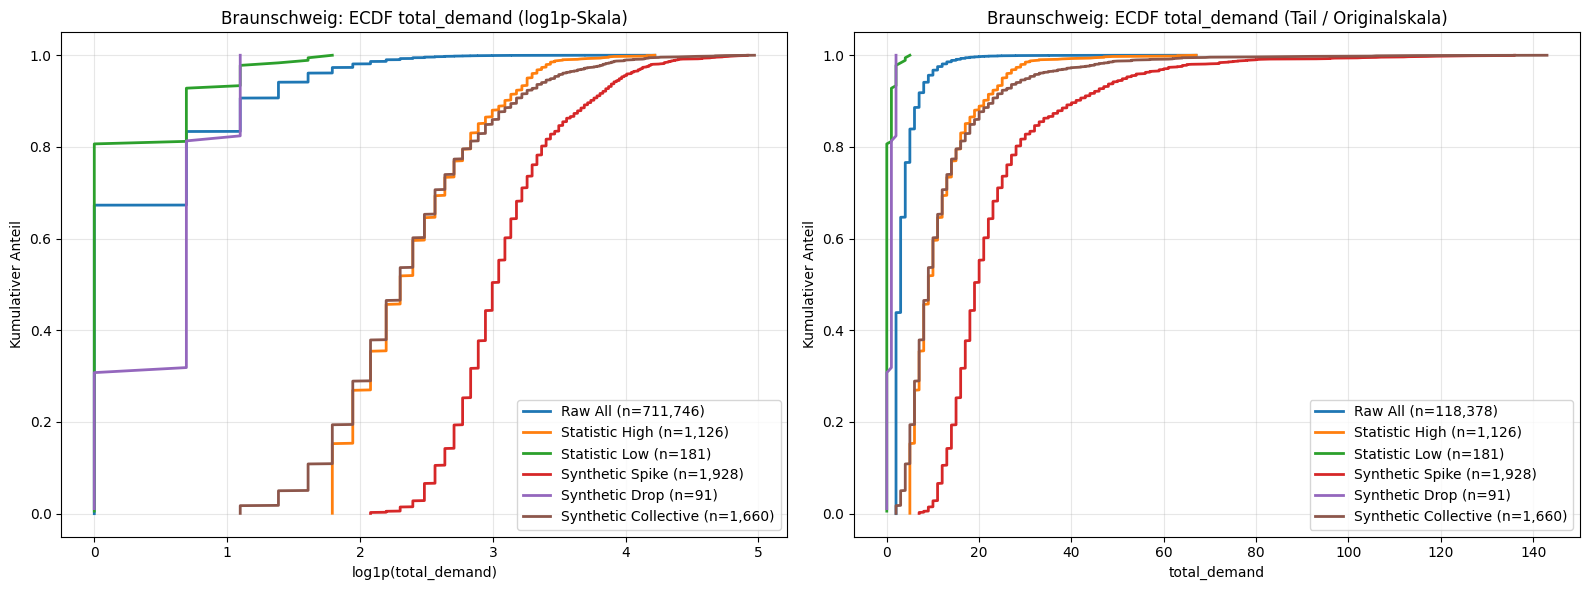

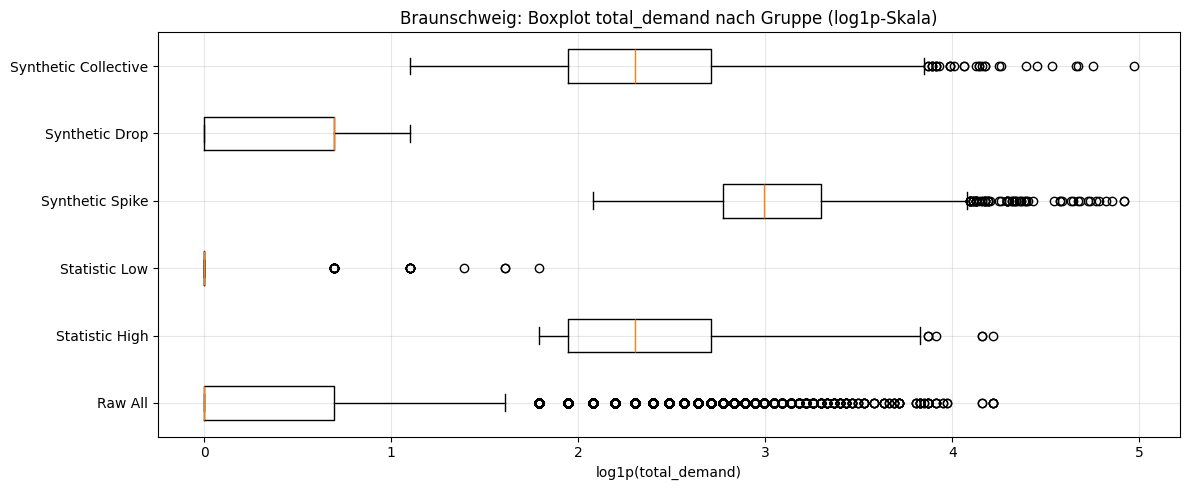

In [25]:
# ============================================================
# Verteilungsvergleich total_demand:
# Raw All vs Statistic High/Low vs Synthetic Spike/Drop/Collective
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CITY = "Braunschweig"   # <- anpassen

# ------------------------------------------------------------
# Daten holen
# ------------------------------------------------------------
raw_df, profile, train_end, val_end = city_raw[CITY]
inj_df = city_injected[CITY].copy()
raw_df = raw_df.copy()

def get_numeric(df, mask, col="total_demand"):
    if col not in df.columns:
        return pd.Series(dtype=float)
    s = pd.to_numeric(df.loc[mask, col], errors="coerce")
    return s[np.isfinite(s)]

raw_all = get_numeric(raw_df, raw_df.index == raw_df.index, "total_demand")

if "label_eval" in raw_df.columns:
    stat_high = get_numeric(raw_df, raw_df["label_eval"] == "anomal_high")
    stat_low  = get_numeric(raw_df, raw_df["label_eval"] == "anomal_low")
else:
    stat_high = pd.Series(dtype=float)
    stat_low  = pd.Series(dtype=float)

if {"synth_label", "synth_type"}.issubset(inj_df.columns):
    synth_spike = get_numeric(inj_df, (inj_df["synth_label"] == 1) & (inj_df["synth_type"] == "point_spike"))
    synth_drop  = get_numeric(inj_df, (inj_df["synth_label"] == 1) & (inj_df["synth_type"] == "point_drop"))
    synth_coll  = get_numeric(inj_df, (inj_df["synth_label"] == 1) & (inj_df["synth_type"] == "collective"))
else:
    synth_spike = pd.Series(dtype=float)
    synth_drop  = pd.Series(dtype=float)
    synth_coll  = pd.Series(dtype=float)

series_dict = {
    "Raw All": raw_all,
    "Statistic High": stat_high,
    "Statistic Low": stat_low,
    "Synthetic Spike": synth_spike,
    "Synthetic Drop": synth_drop,
    "Synthetic Collective": synth_coll,
}

# ------------------------------------------------------------
# Kompakte Tabelle
# ------------------------------------------------------------
def summarize(name, s):
    s = pd.Series(s).dropna()
    if len(s) == 0:
        return {
            "Gruppe": name,
            "n": 0,
            "Ø Demand": np.nan,
            "Median": np.nan,
            "p95": np.nan,
            "p99": np.nan,
            "Max": np.nan,
        }
    return {
        "Gruppe": name,
        "n": len(s),
        "Ø Demand": round(s.mean(), 2),
        "Median": round(s.median(), 2),
        "p95": round(s.quantile(0.95), 2),
        "p99": round(s.quantile(0.99), 2),
        "Max": round(s.max(), 2),
    }

summary_df = pd.DataFrame([summarize(name, s) for name, s in series_dict.items()])
display(summary_df)

# ------------------------------------------------------------
# Plot: ECDF + Zoom-ECDF
# ------------------------------------------------------------
def plot_ecdf(ax, s, label, log_x=False):
    s = pd.Series(s).dropna().sort_values().to_numpy()
    if len(s) == 0:
        return
    y = np.arange(1, len(s) + 1) / len(s)
    x = np.log1p(s) if log_x else s
    ax.plot(x, y, linewidth=2, label=f"{label} (n={len(s):,})")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Links: volle Verteilung
for name, s in series_dict.items():
    plot_ecdf(axes[0], s, name, log_x=True)

axes[0].set_title(f"{CITY}: ECDF total_demand (log1p-Skala)")
axes[0].set_xlabel("log1p(total_demand)")
axes[0].set_ylabel("Kumulativer Anteil")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Rechts: Zoom auf Tail / Originalskala
tail_dict = {
    "Raw All": raw_all[raw_all >= raw_all.quantile(0.90)],
    "Statistic High": stat_high,
    "Statistic Low": stat_low,
    "Synthetic Spike": synth_spike,
    "Synthetic Drop": synth_drop,
    "Synthetic Collective": synth_coll,
}
for name, s in tail_dict.items():
    plot_ecdf(axes[1], s, name, log_x=False)

axes[1].set_title(f"{CITY}: ECDF total_demand (Tail / Originalskala)")
axes[1].set_xlabel("total_demand")
axes[1].set_ylabel("Kumulativer Anteil")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Optional: zusätzlich Boxplot auf log1p-Skala
# ------------------------------------------------------------
labels = []
data = []
for name, s in series_dict.items():
    s = pd.Series(s).dropna()
    if len(s) > 0:
        labels.append(name)
        data.append(np.log1p(s))

plt.figure(figsize=(12, 5))
plt.boxplot(data, vert=False, labels=labels, showfliers=True)
plt.title(f"{CITY}: Boxplot total_demand nach Gruppe (log1p-Skala)")
plt.xlabel("log1p(total_demand)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()